In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

directory_path = '/content/drive/MyDrive/processed_ck_pt/CK+48'
if os.path.exists(directory_path):
    items = os.listdir(directory_path)
    print(f"Found {len(items)} items in {directory_path}:")
    for item in sorted(items):
        print(item)
else:
    print(f"The directory {directory_path} does not exist.")

Found 6 items in /content/drive/MyDrive/processed_ck_pt/CK+48:
Angry
Disgust
Fear
Happy
Sad
Surprise


### 1. Setup Data Loader
Create a custom PyTorch dataset to load the `.pt` files directly from the directory and map the emotions to their corresponding class indices.

In [ ]:
import os
import time
import torch
import timm
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm

# Map CK+48 subfolders to standard class indices
CLASS_MAPPING = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'sad': 4,
    'surprise': 5
}

class PTFolderDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []
        for cls_name in os.listdir(root_dir):
            cls_dir = os.path.join(root_dir, cls_name)
            if not os.path.isdir(cls_dir):
                continue

            target_label = None
            for t_name, t_idx in CLASS_MAPPING.items():
                if t_name.lower() in cls_name.lower():
                    target_label = t_idx
                    break

            if target_label is None:
                continue

            for file in os.listdir(cls_dir):
                if file.endswith('.pt'):
                    self.samples.append((os.path.join(cls_dir, file), target_label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        tensor = torch.load(path, map_location='cpu')
        if tensor.dim() == 4 and tensor.size(0) == 1:
            tensor = tensor.squeeze(0)
        return tensor, label

dataset_path = '/content/drive/MyDrive/processed_ck_pt/CK+48'
test_dataset = PTFolderDataset(dataset_path)
print(f"Loaded test dataset with {len(test_dataset)} samples.")

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

### 2. Evaluation Function
This function calculates Accuracy, Recall, Precision, and F1-score using scikit-learn, and records the average inference time per sample to compute the FPS (Frames Per Second).

In [ ]:
def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    total_inference_time = 0.0
    total_samples = 0

    # Warm-up phase to ensure accurate timing
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    try:
        with torch.no_grad():
            for _ in range(10):
                _ = model(dummy_input)
    except Exception:
        pass

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)

            # Timing start
            if device.type == 'cuda':
                torch.cuda.synchronize()
            start_time = time.time()

            outputs = model(inputs)

            # Timing end
            if device.type == 'cuda':
                torch.cuda.synchronize()
            total_inference_time += (time.time() - start_time)

            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            total_samples += inputs.size(0)

    # Calculate Metrics using Macro-averaging (Macro-Accuracy per user instruction)
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    # Average inference time per sample in milliseconds
    avg_inference_time_ms = (total_inference_time / total_samples * 1000) if total_samples > 0 else 0

    # FPS calculation per user formula: FPS = 1000 / t (where t is time in ms)
    fps = (1000.0 / avg_inference_time_ms) if avg_inference_time_ms > 0 else 0

    return {
        'Macro-Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Avg Inference Time (ms)': avg_inference_time_ms,
        'FPS': fps
    }

### 3. Run Pipeline Over All Saved Models
This script automatically walks through your `Saved_Model` directory, infers the model architecture based on the `.pth` filename, loads the state dictionary, and evaluates it on the CK+48 dataset. It summarizes all results into a single table.

In [ ]:
# !pip install -U timm transformers einops Pillow -q
# !pip install mamba-ssm --no-build-isolation
# !pip install mambavision --no-deps -q

!pip install -U timm transformers einops Pillow -q

!pip install mambavision --no-deps -q

import os
from glob import glob

wheel_dir = "/content/drive/MyDrive/pip_wheels"

# Find all mamba_ssm wheels
wheel_files = glob(os.path.join(wheel_dir, "mamba_ssm*.whl"))

if len(wheel_files) == 0:
    print("No wheel found.")
else:
    latest_wheel = sorted(wheel_files)[-1]

    print("Installing:")
    print(latest_wheel)

    !pip install --no-deps "{latest_wheel}"

In [ ]:
import sys
!pip install thop -q
from thop import profile

# RAF-DB

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

models_dir = '/content/drive/MyDrive/Saved_Model/RAF-DB'
results = []

def infer_architecture(filename):
    filename = filename.lower()
    if 'vit_base' in filename: return 'vit_base_patch16_224'
    if 'vit_small' in filename: return 'vit_small_patch16_224'
    if 'vit_tiny' in filename: return 'vit_tiny_patch16_224'
    if 'resnet18' in filename: return 'resnet18'
    if 'resnet50' in filename: return 'resnet50'
    if 'resnet101' in filename: return 'resnet101'
    if 'mamba_tiny' in filename: return 'mamba_vision_T'
    if 'mamba_small' in filename: return 'mamba_vision_S'
    if 'mamba_base' in filename: return 'mamba_vision_B'
    return None

for root, dirs, files in os.walk(models_dir):
    for file in files:
        if file.endswith('.pth'):
            model_path = os.path.join(root, file)
            arch = infer_architecture(file)

            if not arch:
                print(f"Skipping {file}: Could not infer architecture from filename.")
                continue

            print(f"\nEvaluating {file} (Architecture: {arch})...")
            try:
                # Instantiate model
                if 'mamba_vision' in arch:
                    from mambavision import create_model as create_mamba_model
                    model = create_mamba_model(arch, pretrained=False, num_classes=6)
                else:
                    model = timm.create_model(arch, pretrained=False, num_classes=6)

                state_dict = torch.load(model_path, map_location=device)

                # Handle typical resnet state_dict key mismatches (e.g. fc.1.weight -> fc.weight)
                if 'fc.1.weight' in state_dict:
                    state_dict['fc.weight'] = state_dict.pop('fc.1.weight')
                if 'fc.1.bias' in state_dict:
                    state_dict['fc.bias'] = state_dict.pop('fc.1.bias')

                model.load_state_dict(state_dict, strict=False)
                model.to(device)

                # Evaluate
                metrics = evaluate_model(model, test_loader, device)
                metrics['Model File'] = file
                metrics['Dataset Folder'] = os.path.basename(root)

                results.append(metrics)
                print(f"Success! Accuracy: {metrics['Accuracy']:.4f}, FPS: {metrics['FPS']:.2f}")

                # Free up memory
                del model
                if device.type == 'cuda':
                    torch.cuda.empty_cache()

            except Exception as e:
                print(f"Failed to evaluate {file}: {e}")

if results:
    df_results = pd.DataFrame(results)
    # Reorder columns for better readability
    cols = ['Model File', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Avg Inference Time (ms)', 'FPS']
    df_results = df_results[[c for c in cols if c in df_results.columns]]
    print("\n=== FINAL EVALUATION RESULTS ===")
    display(df_results)
else:
    print("\nNo evaluation results generated.")

Using device: cuda

Evaluating resnet18_best.pth (Architecture: resnet18)...


Success! Accuracy: 0.7292, FPS: 750.20

Evaluating resnet50_best.pth (Architecture: resnet50)...


Success! Accuracy: 0.6936, FPS: 371.15

Evaluating resnet101_best.pth (Architecture: resnet101)...


Success! Accuracy: 0.7530, FPS: 213.71

Evaluating vit_tiny_best.pth (Architecture: vit_tiny_patch16_224)...


Success! Accuracy: 0.7001, FPS: 854.09

Evaluating vit_small_best.pth (Architecture: vit_small_patch16_224)...


...

Success! Accuracy: 0.6958, FPS: 90.29

Evaluating mamba_tiny_best.pth (Architecture: mamba_vision_T)...


Success! Accuracy: 0.7325, FPS: 316.41

Evaluating mamba_small_best.pth (Architecture: mamba_vision_S)...


Success! Accuracy: 0.7206, FPS: 209.61

Evaluating mamba_base_best.pth (Architecture: mamba_vision_B)...


Success! Accuracy: 0.7594, FPS: 110.41

=== FINAL EVALUATION RESULTS ===


,Model File,Accuracy,Precision,Recall,F1-Score,Avg Inference Time (ms),FPS
0,resnet18_best.pth,0.729234,0.647934,0.654717,0.625396,1.332980,750.198939
1,resnet50_best.pth,0.693635,0.617904,0.568044,0.545828,2.694338,371.148716
2,resnet101_best.pth,0.752967,0.714147,0.670959,0.635498,4.679141,213.714426
3,vit_tiny_best.pth,0.700108,0.698250,0.555859,0.528716,1.170843,854.085261
4,vit_small_best.pth,0.750809,0.655077,0.644824,0.611399,2.836984,352.486997
5,vit_base_best.pth,0.695793,0.635312,0.596950,0.599419,11.076017,90.285163
6,mamba_tiny_best.pth,0.732470,0.715065,0.648787,0.643927,3.160450,316.410593
7,mamba_small_best.pth,0.720604,0.667113,0.613355,0.602966,4.770878,209.605039
8,mamba_base_best.pth,0.759439,0.653132,0.684177,0.629200,9.057121,110.410357


# KDEF

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

models_dir = '/content/drive/MyDrive/Saved_Model/KDEF/'
results = []

def infer_architecture(filename):
    filename = filename.lower()
    if 'vit_base' in filename: return 'vit_base_patch16_224'
    if 'vit_small' in filename: return 'vit_small_patch16_224'
    if 'vit_tiny' in filename: return 'vit_tiny_patch16_224'
    if 'resnet18' in filename: return 'resnet18'
    if 'resnet50' in filename: return 'resnet50'
    if 'resnet101' in filename: return 'resnet101'
    if 'mamba_tiny' in filename: return 'mamba_vision_T'
    if 'mamba_small' in filename: return 'mamba_vision_S'
    if 'mamba_base' in filename: return 'mamba_vision_B'
    return None

for root, dirs, files in os.walk(models_dir):
    for file in files:
        if file.endswith('.pth'):
            model_path = os.path.join(root, file)
            arch = infer_architecture(file)

            if not arch:
                print(f"Skipping {file}: Could not infer architecture from filename.")
                continue

            print(f"\nEvaluating {file} (Architecture: {arch})...")
            try:
                # Instantiate model
                if 'mamba_vision' in arch:
                    from mambavision import create_model as create_mamba_model
                    model = create_mamba_model(arch, pretrained=False, num_classes=6)
                else:
                    model = timm.create_model(arch, pretrained=False, num_classes=6)

                state_dict = torch.load(model_path, map_location=device)

                # Handle typical resnet state_dict key mismatches (e.g. fc.1.weight -> fc.weight)
                if 'fc.1.weight' in state_dict:
                    state_dict['fc.weight'] = state_dict.pop('fc.1.weight')
                if 'fc.1.bias' in state_dict:
                    state_dict['fc.bias'] = state_dict.pop('fc.1.bias')

                model.load_state_dict(state_dict, strict=False)
                model.to(device)

                # Evaluate
                metrics = evaluate_model(model, test_loader, device)
                metrics['Model File'] = file
                metrics['Dataset Folder'] = os.path.basename(root)

                results.append(metrics)
                print(f"Success! Accuracy: {metrics['Accuracy']:.4f}, FPS: {metrics['FPS']:.2f}")

                # Free up memory
                del model
                if device.type == 'cuda':
                    torch.cuda.empty_cache()

            except Exception as e:
                print(f"Failed to evaluate {file}: {e}")

if results:
    df_results = pd.DataFrame(results)
    # Reorder columns for better readability
    cols = ['Model File', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Avg Inference Time (ms)', 'FPS']
    df_results = df_results[[c for c in cols if c in df_results.columns]]
    print("\n=== FINAL EVALUATION RESULTS ===")
    display(df_results)
else:
    print("\nNo evaluation results generated.")

Using device: cuda

Evaluating resnet101_best.pth (Architecture: resnet101)...


Success! Accuracy: 0.4509, FPS: 189.70

Evaluating vit_tiny_best.pth (Architecture: vit_tiny_patch16_224)...


Success! Accuracy: 0.4552, FPS: 728.71

Evaluating vit_small_best.pth (Architecture: vit_small_patch16_224)...


Success! Accuracy: 0.6828, FPS: 305.95

Evaluating vit_base_best.pth (Architecture: vit_base_patch16_224)...


Success! Accuracy: 0.5707, FPS: 74.31

Evaluating mamba_tiny_best.pth (Architecture: mamba_vision_T)...


...

Success! Accuracy: 0.4337, FPS: 184.70

Evaluating resnet18_best.pth (Architecture: resnet18)...


Success! Accuracy: 0.2513, FPS: 912.68

Evaluating resnet50_best.pth (Architecture: resnet50)...


Success! Accuracy: 0.3560, FPS: 327.80

Evaluating mamba_base_best.pth (Architecture: mamba_vision_B)...


Success! Accuracy: 0.4358, FPS: 98.14

=== FINAL EVALUATION RESULTS ===


,Model File,Accuracy,Precision,Recall,F1-Score,Avg Inference Time (ms),FPS
0,resnet101_best.pth,0.450917,0.506543,0.390549,0.323013,5.271472,189.700322
1,vit_tiny_best.pth,0.455232,0.492964,0.385667,0.327161,1.372285,728.711395
2,vit_small_best.pth,0.682848,0.672880,0.626173,0.620718,3.268476,305.952947
3,vit_base_best.pth,0.570658,0.616530,0.510638,0.504702,13.456425,74.313944
4,mamba_tiny_best.pth,0.484358,0.669564,0.374924,0.325049,3.725543,268.417240
5,mamba_small_best.pth,0.433657,0.593319,0.451154,0.362364,5.414161,184.700830
6,resnet18_best.pth,0.251348,0.358699,0.204286,0.117780,1.095675,912.679328
7,resnet50_best.pth,0.355987,0.379557,0.275036,0.193335,3.050602,327.804098
8,mamba_base_best.pth,0.435814,0.536185,0.459307,0.356710,10.189274,98.142417


# FER2013

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

models_dir = '/content/drive/MyDrive/Saved_Model/FER2013/'
results = []

def infer_architecture(filename):
    filename = filename.lower()
    if 'vit_base' in filename: return 'vit_base_patch16_224'
    if 'vit_small' in filename: return 'vit_small_patch16_224'
    if 'vit_tiny' in filename: return 'vit_tiny_patch16_224'
    if 'resnet18' in filename: return 'resnet18'
    if 'resnet50' in filename: return 'resnet50'
    if 'resnet101' in filename: return 'resnet101'
    if 'mamba_tiny' in filename: return 'mamba_vision_T'
    if 'mamba_small' in filename: return 'mamba_vision_S'
    if 'mamba_base' in filename: return 'mamba_vision_B'
    return None

for root, dirs, files in os.walk(models_dir):
    for file in files:
        if file.endswith('.pth'):
            model_path = os.path.join(root, file)
            arch = infer_architecture(file)

            if not arch:
                print(f"Skipping {file}: Could not infer architecture from filename.")
                continue

            print(f"\nEvaluating {file} (Architecture: {arch})...")
            try:
                # Instantiate model
                if 'mamba_vision' in arch:
                    from mambavision import create_model as create_mamba_model
                    model = create_mamba_model(arch, pretrained=False, num_classes=6)
                else:
                    model = timm.create_model(arch, pretrained=False, num_classes=6)

                state_dict = torch.load(model_path, map_location=device)

                # Handle typical resnet state_dict key mismatches (e.g. fc.1.weight -> fc.weight)
                if 'fc.1.weight' in state_dict:
                    state_dict['fc.weight'] = state_dict.pop('fc.1.weight')
                if 'fc.1.bias' in state_dict:
                    state_dict['fc.bias'] = state_dict.pop('fc.1.bias')

                model.load_state_dict(state_dict, strict=False)
                model.to(device)

                # Evaluate
                metrics = evaluate_model(model, test_loader, device)
                metrics['Model File'] = file
                metrics['Dataset Folder'] = os.path.basename(root)

                results.append(metrics)
                print(f"Success! Accuracy: {metrics['Accuracy']:.4f}, FPS: {metrics['FPS']:.2f}")

                # Free up memory
                del model
                if device.type == 'cuda':
                    torch.cuda.empty_cache()

            except Exception as e:
                print(f"Failed to evaluate {file}: {e}")

if results:
    df_results = pd.DataFrame(results)
    # Reorder columns for better readability
    cols = ['Model File', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Avg Inference Time (ms)', 'FPS']
    df_results = df_results[[c for c in cols if c in df_results.columns]]
    print("\n=== FINAL EVALUATION RESULTS ===")
    display(df_results)
else:
    print("\nNo evaluation results generated.")

Using device: cuda

Evaluating resnet18_best.pth (Architecture: resnet18)...


Success! Accuracy: 0.7195, FPS: 920.39

Evaluating resnet50_best.pth (Architecture: resnet50)...


Success! Accuracy: 0.7303, FPS: 320.40

Evaluating resnet101_best.pth (Architecture: resnet101)...


Success! Accuracy: 0.6570, FPS: 172.90

Evaluating vit_tiny_best.pth (Architecture: vit_tiny_patch16_224)...


Success! Accuracy: 0.7789, FPS: 788.02

Evaluating vit_small_best.pth (Architecture: vit_small_patch16_224)...


...

Success! Accuracy: 0.7487, FPS: 74.35

Evaluating mamba_tiny_best.pth (Architecture: mamba_vision_T)...


Success! Accuracy: 0.7120, FPS: 280.90

Evaluating mamba_small_best.pth (Architecture: mamba_vision_S)...


Success! Accuracy: 0.7983, FPS: 187.89

Evaluating mamba_base_best.pth (Architecture: mamba_vision_B)...


Success! Accuracy: 0.7864, FPS: 101.23

=== FINAL EVALUATION RESULTS ===


,Model File,Accuracy,Precision,Recall,F1-Score,Avg Inference Time (ms),FPS
0,resnet18_best.pth,0.719525,0.646026,0.652457,0.631605,1.086498,920.388125
1,resnet50_best.pth,0.730313,0.674174,0.664537,0.656857,3.121069,320.402994
2,resnet101_best.pth,0.656958,0.624082,0.595727,0.556342,5.783681,172.900282
3,vit_tiny_best.pth,0.778857,0.744620,0.719395,0.706418,1.268997,788.023827
4,vit_small_best.pth,0.772384,0.727661,0.694813,0.692947,3.565848,280.438227
5,vit_base_best.pth,0.748652,0.723889,0.699834,0.680968,13.450132,74.348715
6,mamba_tiny_best.pth,0.711974,0.693773,0.653008,0.638497,3.559927,280.904650
7,mamba_small_best.pth,0.798274,0.736979,0.735280,0.722782,5.322323,187.887878
8,mamba_base_best.pth,0.786408,0.726261,0.721947,0.714193,9.878964,101.225188


# RAF-DB + KDEF

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

models_dir = '/content/drive/MyDrive/Saved_Model/RAF-DB+KDEF/'
results = []

def infer_architecture(filename):
    filename = filename.lower()
    if 'vit_base' in filename: return 'vit_base_patch16_224'
    if 'vit_small' in filename: return 'vit_small_patch16_224'
    if 'vit_tiny' in filename: return 'vit_tiny_patch16_224'
    if 'resnet18' in filename: return 'resnet18'
    if 'resnet50' in filename: return 'resnet50'
    if 'resnet101' in filename: return 'resnet101'
    if 'mamba_tiny' in filename: return 'mamba_vision_T'
    if 'mamba_small' in filename: return 'mamba_vision_S'
    if 'mamba_base' in filename: return 'mamba_vision_B'
    return None

for root, dirs, files in os.walk(models_dir):
    for file in files:
        if file.endswith('.pth'):
            model_path = os.path.join(root, file)
            arch = infer_architecture(file)

            if not arch:
                print(f"Skipping {file}: Could not infer architecture from filename.")
                continue

            print(f"\nEvaluating {file} (Architecture: {arch})...")
            try:
                # Instantiate model
                if 'mamba_vision' in arch:
                    from mambavision import create_model as create_mamba_model
                    model = create_mamba_model(arch, pretrained=False, num_classes=6)
                else:
                    model = timm.create_model(arch, pretrained=False, num_classes=6)

                state_dict = torch.load(model_path, map_location=device)

                # Handle typical resnet state_dict key mismatches (e.g. fc.1.weight -> fc.weight)
                if 'fc.1.weight' in state_dict:
                    state_dict['fc.weight'] = state_dict.pop('fc.1.weight')
                if 'fc.1.bias' in state_dict:
                    state_dict['fc.bias'] = state_dict.pop('fc.1.bias')

                model.load_state_dict(state_dict, strict=False)
                model.to(device)

                # Evaluate
                metrics = evaluate_model(model, test_loader, device)
                metrics['Model File'] = file
                metrics['Dataset Folder'] = os.path.basename(root)

                results.append(metrics)
                print(f"Success! Accuracy: {metrics['Accuracy']:.4f}, FPS: {metrics['FPS']:.2f}")

                # Free up memory
                del model
                if device.type == 'cuda':
                    torch.cuda.empty_cache()

            except Exception as e:
                print(f"Failed to evaluate {file}: {e}")

if results:
    df_results = pd.DataFrame(results)
    # Reorder columns for better readability
    cols = ['Model File', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Avg Inference Time (ms)', 'FPS']
    df_results = df_results[[c for c in cols if c in df_results.columns]]
    print("\n=== FINAL EVALUATION RESULTS ===")
    display(df_results)
else:
    print("\nNo evaluation results generated.")

Using device: cuda

Evaluating resnet18_best.pth (Architecture: resnet18)...


Success! Accuracy: 0.7487, FPS: 917.49

Evaluating resnet50_best.pth (Architecture: resnet50)...


Success! Accuracy: 0.6828, FPS: 324.35

Evaluating resnet101_best.pth (Architecture: resnet101)...


Success! Accuracy: 0.6893, FPS: 169.41

Evaluating vit_tiny_best.pth (Architecture: vit_tiny_patch16_224)...


Success! Accuracy: 0.7573, FPS: 781.68

Evaluating vit_small_best.pth (Architecture: vit_small_patch16_224)...


...

Success! Accuracy: 0.8015, FPS: 75.09

Evaluating mamba_tiny_best.pth (Architecture: mamba_vision_T)...


Success! Accuracy: 0.7508, FPS: 285.07

Evaluating mamba_small_best.pth (Architecture: mamba_vision_S)...


Success! Accuracy: 0.7497, FPS: 190.09

Evaluating mamba_base_best.pth (Architecture: mamba_vision_B)...


Success! Accuracy: 0.7368, FPS: 99.98

=== FINAL EVALUATION RESULTS ===


,Model File,Accuracy,Precision,Recall,F1-Score,Avg Inference Time (ms),FPS
0,resnet18_best.pth,0.748652,0.665453,0.678164,0.650533,1.089929,917.491071
1,resnet50_best.pth,0.682848,0.593773,0.586890,0.540298,3.083125,324.346196
2,resnet101_best.pth,0.689320,0.645652,0.609045,0.580786,5.902937,169.407205
3,vit_tiny_best.pth,0.757282,0.678151,0.669570,0.641704,1.279297,781.679157
4,vit_small_best.pth,0.763754,0.796670,0.658119,0.649139,3.613535,276.737342
5,vit_base_best.pth,0.801510,0.768929,0.739255,0.697613,13.316632,75.094065
6,mamba_tiny_best.pth,0.750809,0.659809,0.658841,0.632842,3.507904,285.070537
7,mamba_small_best.pth,0.749730,0.642277,0.678558,0.648201,5.260772,190.086159
8,mamba_base_best.pth,0.736785,0.685871,0.655211,0.635778,10.001826,99.981748


# FER2013 + KDEF

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

models_dir = '/content/drive/MyDrive/Saved_Model/FER2013+KDEF/'
results = []

def infer_architecture(filename):
    filename = filename.lower()
    if 'vit_base' in filename: return 'vit_base_patch16_224'
    if 'vit_small' in filename: return 'vit_small_patch16_224'
    if 'vit_tiny' in filename: return 'vit_tiny_patch16_224'
    if 'resnet18' in filename: return 'resnet18'
    if 'resnet50' in filename: return 'resnet50'
    if 'resnet101' in filename: return 'resnet101'
    if 'mamba_tiny' in filename: return 'mamba_vision_T'
    if 'mamba_small' in filename: return 'mamba_vision_S'
    if 'mamba_base' in filename: return 'mamba_vision_B'
    return None

for root, dirs, files in os.walk(models_dir):
    for file in files:
        if file.endswith('.pth'):
            model_path = os.path.join(root, file)
            arch = infer_architecture(file)

            if not arch:
                print(f"Skipping {file}: Could not infer architecture from filename.")
                continue

            print(f"\nEvaluating {file} (Architecture: {arch})...")
            try:
                # Instantiate model
                if 'mamba_vision' in arch:
                    from mambavision import create_model as create_mamba_model
                    model = create_mamba_model(arch, pretrained=False, num_classes=6)
                else:
                    model = timm.create_model(arch, pretrained=False, num_classes=6)

                state_dict = torch.load(model_path, map_location=device)

                # Handle typical resnet state_dict key mismatches (e.g. fc.1.weight -> fc.weight)
                if 'fc.1.weight' in state_dict:
                    state_dict['fc.weight'] = state_dict.pop('fc.1.weight')
                if 'fc.1.bias' in state_dict:
                    state_dict['fc.bias'] = state_dict.pop('fc.1.bias')

                model.load_state_dict(state_dict, strict=False)
                model.to(device)

                # Evaluate
                metrics = evaluate_model(model, test_loader, device)
                metrics['Model File'] = file
                metrics['Dataset Folder'] = os.path.basename(root)

                results.append(metrics)
                print(f"Success! Accuracy: {metrics['Accuracy']:.4f}, FPS: {metrics['FPS']:.2f}")

                # Free up memory
                del model
                if device.type == 'cuda':
                    torch.cuda.empty_cache()

            except Exception as e:
                print(f"Failed to evaluate {file}: {e}")

if results:
    df_results = pd.DataFrame(results)
    # Reorder columns for better readability
    cols = ['Model File', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Avg Inference Time (ms)', 'FPS']
    df_results = df_results[[c for c in cols if c in df_results.columns]]
    print("\n=== FINAL EVALUATION RESULTS ===")
    display(df_results)
else:
    print("\nNo evaluation results generated.")

Using device: cuda

Evaluating resnet18_best.pth (Architecture: resnet18)...


Success! Accuracy: 0.7228, FPS: 919.15

Evaluating resnet50_best.pth (Architecture: resnet50)...


Success! Accuracy: 0.7206, FPS: 313.56

Evaluating resnet101_best.pth (Architecture: resnet101)...


Success! Accuracy: 0.7896, FPS: 171.97

Evaluating vit_tiny_best.pth (Architecture: vit_tiny_patch16_224)...


Success! Accuracy: 0.7077, FPS: 755.51

Evaluating vit_small_best.pth (Architecture: vit_small_patch16_224)...


...

Success! Accuracy: 0.7638, FPS: 74.31

Evaluating mamba_tiny_best.pth (Architecture: mamba_vision_T)...


Success! Accuracy: 0.7681, FPS: 281.61

Evaluating mamba_small_best.pth (Architecture: mamba_vision_S)...


Success! Accuracy: 0.7961, FPS: 189.23

Evaluating mamba_base_best.pth (Architecture: mamba_vision_B)...


Success! Accuracy: 0.8306, FPS: 99.32

=== FINAL EVALUATION RESULTS ===


,Model File,Accuracy,Precision,Recall,F1-Score,Avg Inference Time (ms),FPS
0,resnet18_best.pth,0.722762,0.683260,0.652651,0.642020,1.087957,919.153575
1,resnet50_best.pth,0.720604,0.687128,0.659690,0.635940,3.189142,313.563966
2,resnet101_best.pth,0.789644,0.743482,0.732577,0.720782,5.814899,171.972040
3,vit_tiny_best.pth,0.707659,0.694268,0.653819,0.628494,1.323606,755.511940
4,vit_small_best.pth,0.824164,0.763767,0.769468,0.760932,3.567119,280.338300
5,vit_base_best.pth,0.763754,0.704867,0.698800,0.677388,13.456475,74.313668
6,mamba_tiny_best.pth,0.768069,0.772087,0.728045,0.704157,3.550965,281.613576
7,mamba_small_best.pth,0.796117,0.761825,0.738273,0.735401,5.284661,189.226879
8,mamba_base_best.pth,0.830636,0.768828,0.771882,0.767555,10.068794,99.316764


# RAF-DB + FER2013

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

models_dir = '/content/drive/MyDrive/Saved_Model/RAF-DB+FER2013/'
results = []

def infer_architecture(filename):
    filename = filename.lower()
    if 'vit_base' in filename: return 'vit_base_patch16_224'
    if 'vit_small' in filename: return 'vit_small_patch16_224'
    if 'vit_tiny' in filename: return 'vit_tiny_patch16_224'
    if 'resnet18' in filename: return 'resnet18'
    if 'resnet50' in filename: return 'resnet50'
    if 'resnet101' in filename: return 'resnet101'
    if 'mamba_tiny' in filename: return 'mamba_vision_T'
    if 'mamba_small' in filename: return 'mamba_vision_S'
    if 'mamba_base' in filename: return 'mamba_vision_B'
    return None

for root, dirs, files in os.walk(models_dir):
    for file in files:
        if file.endswith('.pth'):
            model_path = os.path.join(root, file)
            arch = infer_architecture(file)

            if not arch:
                print(f"Skipping {file}: Could not infer architecture from filename.")
                continue

            print(f"\nEvaluating {file} (Architecture: {arch})...")
            try:
                # Instantiate model
                if 'mamba_vision' in arch:
                    from mambavision import create_model as create_mamba_model
                    model = create_mamba_model(arch, pretrained=False, num_classes=6)
                else:
                    model = timm.create_model(arch, pretrained=False, num_classes=6)

                state_dict = torch.load(model_path, map_location=device)

                # Handle typical resnet state_dict key mismatches (e.g. fc.1.weight -> fc.weight)
                if 'fc.1.weight' in state_dict:
                    state_dict['fc.weight'] = state_dict.pop('fc.1.weight')
                if 'fc.1.bias' in state_dict:
                    state_dict['fc.bias'] = state_dict.pop('fc.1.bias')

                model.load_state_dict(state_dict, strict=False)
                model.to(device)

                # Evaluate
                metrics = evaluate_model(model, test_loader, device)
                metrics['Model File'] = file
                metrics['Dataset Folder'] = os.path.basename(root)

                results.append(metrics)
                print(f"Success! Accuracy: {metrics['Accuracy']:.4f}, FPS: {metrics['FPS']:.2f}")

                # Free up memory
                del model
                if device.type == 'cuda':
                    torch.cuda.empty_cache()

            except Exception as e:
                print(f"Failed to evaluate {file}: {e}")

if results:
    df_results = pd.DataFrame(results)
    # Reorder columns for better readability
    cols = ['Model File', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Avg Inference Time (ms)', 'FPS']
    df_results = df_results[[c for c in cols if c in df_results.columns]]
    print("\n=== FINAL EVALUATION RESULTS ===")
    display(df_results)
else:
    print("\nNo evaluation results generated.")

Using device: cuda

Evaluating resnet50_best.pth (Architecture: resnet50)...


Success! Accuracy: 0.7044, FPS: 303.31

Evaluating resnet101_best.pth (Architecture: resnet101)...


Success! Accuracy: 0.6645, FPS: 166.94

Evaluating vit_tiny_best.pth (Architecture: vit_tiny_patch16_224)...


Success! Accuracy: 0.7638, FPS: 774.97

Evaluating vit_small_best.pth (Architecture: vit_small_patch16_224)...


Success! Accuracy: 0.7843, FPS: 285.03

Evaluating vit_base_best.pth (Architecture: vit_base_patch16_224)...


...

Success! Accuracy: 0.7756, FPS: 275.90

Evaluating mamba_small_best.pth (Architecture: mamba_vision_S)...


Success! Accuracy: 0.7767, FPS: 193.16

Evaluating resnet18_best.pth (Architecture: resnet18)...


Success! Accuracy: 0.7756, FPS: 917.10

Evaluating mamba_base_best.pth (Architecture: mamba_vision_B)...


Success! Accuracy: 0.7249, FPS: 98.95

=== FINAL EVALUATION RESULTS ===


,Model File,Accuracy,Precision,Recall,F1-Score,Avg Inference Time (ms),FPS
0,resnet50_best.pth,0.704423,0.668723,0.653520,0.624179,3.296940,303.311596
1,resnet101_best.pth,0.664509,0.658998,0.604884,0.577664,5.990327,166.935803
2,vit_tiny_best.pth,0.763754,0.730278,0.710779,0.701968,1.290369,774.971853
3,vit_small_best.pth,0.784250,0.764228,0.735072,0.721305,3.508417,285.028866
4,vit_base_best.pth,0.816613,0.751911,0.735705,0.739295,13.367575,74.807884
5,mamba_tiny_best.pth,0.775620,0.698945,0.704763,0.699067,3.624455,275.903575
6,mamba_small_best.pth,0.776699,0.734536,0.724687,0.717621,5.177007,193.161816
7,resnet18_best.pth,0.775620,0.720924,0.706781,0.704065,1.090390,917.102829
8,mamba_base_best.pth,0.724919,0.727806,0.682607,0.655556,10.105662,98.954432


# RAF-DB + FER2013 + KDEF


In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

models_dir = '/content/drive/MyDrive/Saved_Model/RAF-DB+FER2013+KDEF/'
results = []

def infer_architecture(filename):
    filename = filename.lower()
    if 'vit_base' in filename: return 'vit_base_patch16_224'
    if 'vit_small' in filename: return 'vit_small_patch16_224'
    if 'vit_tiny' in filename: return 'vit_tiny_patch16_224'
    if 'resnet18' in filename: return 'resnet18'
    if 'resnet50' in filename: return 'resnet50'
    if 'resnet101' in filename: return 'resnet101'
    if 'mamba_tiny' in filename: return 'mamba_vision_T'
    if 'mamba_small' in filename: return 'mamba_vision_S'
    if 'mamba_base' in filename: return 'mamba_vision_B'
    return None

for root, dirs, files in os.walk(models_dir):
    for file in files:
        if file.endswith('.pth'):
            model_path = os.path.join(root, file)
            arch = infer_architecture(file)

            if not arch:
                print(f"Skipping {file}: Could not infer architecture from filename.")
                continue

            print(f"\nEvaluating {file} (Architecture: {arch})...")
            try:
                # Instantiate model
                if 'mamba_vision' in arch:
                    from mambavision import create_model as create_mamba_model
                    model = create_mamba_model(arch, pretrained=False, num_classes=6)
                else:
                    model = timm.create_model(arch, pretrained=False, num_classes=6)

                state_dict = torch.load(model_path, map_location=device)

                # Handle typical resnet state_dict key mismatches (e.g. fc.1.weight -> fc.weight)
                if 'fc.1.weight' in state_dict:
                    state_dict['fc.weight'] = state_dict.pop('fc.1.weight')
                if 'fc.1.bias' in state_dict:
                    state_dict['fc.bias'] = state_dict.pop('fc.1.bias')

                model.load_state_dict(state_dict, strict=False)
                model.to(device)

                # Evaluate
                metrics = evaluate_model(model, test_loader, device)
                metrics['Model File'] = file
                metrics['Dataset Folder'] = os.path.basename(root)

                results.append(metrics)
                print(f"Success! Accuracy: {metrics['Accuracy']:.4f}, FPS: {metrics['FPS']:.2f}")

                # Free up memory
                del model
                if device.type == 'cuda':
                    torch.cuda.empty_cache()

            except Exception as e:
                print(f"Failed to evaluate {file}: {e}")

if results:
    df_results = pd.DataFrame(results)
    # Reorder columns for better readability
    cols = ['Model File', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Avg Inference Time (ms)', 'FPS']
    df_results = df_results[[c for c in cols if c in df_results.columns]]
    print("\n=== FINAL EVALUATION RESULTS ===")
    display(df_results)
else:
    print("\nNo evaluation results generated.")

Using device: cuda

Evaluating resnet18_best.pth (Architecture: resnet18)...


Success! Accuracy: 0.7443, FPS: 917.98

Evaluating resnet50_best.pth (Architecture: resnet50)...


Success! Accuracy: 0.7670, FPS: 305.82

Evaluating resnet101_best.pth (Architecture: resnet101)...


Success! Accuracy: 0.7238, FPS: 165.15

Evaluating vit_tiny_best.pth (Architecture: vit_tiny_patch16_224)...


Success! Accuracy: 0.7778, FPS: 779.01

Evaluating vit_small_best.pth (Architecture: vit_small_patch16_224)...


...

Success! Accuracy: 0.8123, FPS: 75.36

Evaluating mamba_tiny_best.pth (Architecture: mamba_vision_T)...


Success! Accuracy: 0.8274, FPS: 287.72

Evaluating mamba_small_best.pth (Architecture: mamba_vision_S)...


Success! Accuracy: 0.7756, FPS: 189.25

Evaluating mamba_base_best.pth (Architecture: mamba_vision_B)...


Success! Accuracy: 0.8350, FPS: 98.08

=== FINAL EVALUATION RESULTS ===


,Model File,Accuracy,Precision,Recall,F1-Score,Avg Inference Time (ms),FPS
0,resnet18_best.pth,0.744337,0.693538,0.678202,0.666893,1.089349,917.979112
1,resnet50_best.pth,0.766990,0.723737,0.705495,0.698203,3.269867,305.822828
2,resnet101_best.pth,0.723840,0.688776,0.683747,0.660820,6.055279,165.145158
3,vit_tiny_best.pth,0.777778,0.728621,0.718992,0.697068,1.283678,779.011693
4,vit_small_best.pth,0.791802,0.745210,0.742866,0.733249,3.643340,274.473431
5,vit_base_best.pth,0.812298,0.769473,0.744064,0.749659,13.269378,75.361482
6,mamba_tiny_best.pth,0.827400,0.781627,0.775663,0.766922,3.475643,287.716555
7,mamba_small_best.pth,0.775620,0.726687,0.735596,0.716272,5.284085,189.247529
8,mamba_base_best.pth,0.834951,0.821299,0.807549,0.795572,10.195563,98.081880


### Evaluation with FLOPs
This version includes the calculation of FLOPs and Parameters using `thop`.

In [ ]:
import warnings
from thop import profile
warnings.filterwarnings('ignore')

# Reference the existing model directory and test_loader
models_dir = '/content/drive/MyDrive/Saved_Model/RAF-DB+FER2013+KDEF/'
results = []

# Using the previously defined infer_architecture function

for root, dirs, files in os.walk(models_dir):
    for file in files:
        if file.endswith('.pth'):
            model_path = os.path.join(root, file)
            arch = infer_architecture(file)
            if not arch: continue

            try:
                if 'mamba_vision' in arch:
                    from mambavision import create_model as create_mamba_model
                    model = create_mamba_model(arch, pretrained=False, num_classes=6)
                else:
                    model = timm.create_model(arch, pretrained=False, num_classes=6)

                model.load_state_dict(torch.load(model_path, map_location='cpu'), strict=False)
                model.to(device)

                # Calculate FLOPs and Params
                dummy_input = torch.randn(1, 3, 224, 224).to(device)
                flops, params = profile(model, inputs=(dummy_input, ), verbose=False)

                # Evaluate standard metrics
                metrics = evaluate_model(model, test_loader, device)
                metrics['Model File'] = file
                metrics['GFLOPs'] = flops / 1e9
                metrics['Params (M)'] = params / 1e6

                results.append(metrics)
                print(f"{file} | GFLOPs: {metrics['GFLOPs']:.2f} | Acc: {metrics['Accuracy']:.4f}")

                del model
                torch.cuda.empty_cache()
            except Exception as e:
                print(f"Error with {file}: {e}")

if results:
    df_final = pd.DataFrame(results)
    cols = ['Model File', 'GFLOPs', 'Params (M)', 'Avg Inference Time (ms)', 'FPS']
    display(df_final[cols])

resnet18_best.pth | GFLOPs: 1.82 | Acc: 0.2740


resnet50_best.pth | GFLOPs: 4.13 | Acc: 0.2265


resnet101_best.pth | GFLOPs: 7.86 | Acc: 0.1845


vit_tiny_best.pth | GFLOPs: 1.07 | Acc: 0.7778


vit_small_best.pth | GFLOPs: 4.24 | Acc: 0.7918


vit_base_best.pth | GFLOPs: 16.85 | Acc: 0.8123


mamba_tiny_best.pth | GFLOPs: 4.47 | Acc: 0.8274


mamba_small_best.pth | GFLOPs: 7.50 | Acc: 0.7756


mamba_base_best.pth | GFLOPs: 14.98 | Acc: 0.8350


,Model File,GFLOPs,Params (M),Avg Inference Time (ms),FPS
0,resnet18_best.pth,1.823525,11.179590,0.983603,1016.670425
1,resnet50_best.pth,4.131707,23.520326,3.291328,303.828742
2,resnet101_best.pth,7.864400,42.512454,5.720945,174.796293
3,vit_tiny_best.pth,1.074660,5.477958,1.076321,929.090857
4,vit_small_best.pth,4.240837,21.572742,3.541260,282.385369
5,vit_base_best.pth,16.847737,85.612806,13.293381,75.225406
6,mamba_tiny_best.pth,4.471244,31.137894,3.438603,290.815742
7,mamba_small_best.pth,7.500903,49.347398,5.408106,184.907601
8,mamba_base_best.pth,14.982410,96.603718,9.854078,101.480828


In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# CHAPTER 4 TABLE GENERATION CODE
# Report-aligned table numbering
#
# Table 4.1   Master Result Table
# Table 4.2   Mean Performance by Model
# Table 4.3   Ignored / not generated
# Table 4.4   Architecture Family Mean
# Table 4.5   Mean by Training Dataset Configuration
# Table 4.6   Collapsed Dataset Diversity Level Summary
# Table 4.7   Ignored / not generated
# Table 4.8   Model Size × Dataset Diversity
# Table 4.9   Gain from Single-Dataset Mean to Three-Dataset
# Table 4.10  Peak Performance per Model
# Table 4.11  Efficiency Metrics
# Table 4.12  Parameters, GFLOPs, FPS, and F1 Comparison
# Table 4.13  Normalized Accuracy–Efficiency Trade-off
# Table 4.14  Final Model Recommendation
# ============================================================


# ============================================================
# 1. TABLE 4.1 — MASTER RESULT TABLE
# ============================================================

rows = []

def add(training_set, model, acc, precision, recall, f1):
    rows.append({
        "Training Set": training_set,
        "Model": model,
        "Accuracy (%)": acc,
        "Precision (%)": precision,
        "Recall (%)": recall,
        "F1 Score (%)": f1
    })


# -----------------------------
# FER-2013
# -----------------------------
add("FER-2013", "ResNet18", 71.95, 64.60, 65.25, 63.16)
add("FER-2013", "ResNet50", 73.03, 67.42, 66.45, 65.69)
add("FER-2013", "ResNet101", 65.70, 62.41, 59.57, 55.63)
add("FER-2013", "ViT-Tiny", 77.89, 74.46, 71.94, 70.64)
add("FER-2013", "ViT-Small", 77.24, 72.77, 69.48, 69.29)
add("FER-2013", "ViT-Base", 74.87, 72.39, 69.98, 68.10)
add("FER-2013", "Mamba-Tiny", 71.20, 69.38, 65.30, 63.85)
add("FER-2013", "Mamba-Small", 79.83, 73.70, 73.53, 72.28)
add("FER-2013", "Mamba-Base", 78.64, 72.63, 72.19, 71.42)


# -----------------------------
# RAF-DB
# -----------------------------
add("RAF-DB", "ResNet18", 72.92, 64.79, 65.47, 62.54)
add("RAF-DB", "ResNet50", 69.36, 61.79, 56.80, 54.58)
add("RAF-DB", "ResNet101", 75.30, 71.41, 67.10, 63.55)
add("RAF-DB", "ViT-Tiny", 70.01, 69.83, 55.59, 52.87)
add("RAF-DB", "ViT-Small", 75.08, 65.51, 64.48, 61.14)
add("RAF-DB", "ViT-Base", 69.58, 63.53, 59.69, 59.94)
add("RAF-DB", "Mamba-Tiny", 73.25, 71.51, 64.88, 64.39)
add("RAF-DB", "Mamba-Small", 72.06, 66.71, 61.34, 60.30)
add("RAF-DB", "Mamba-Base", 75.94, 65.31, 68.42, 62.92)


# -----------------------------
# KDEF
# -----------------------------
add("KDEF", "ResNet18", 25.13, 35.87, 20.43, 11.78)
add("KDEF", "ResNet50", 35.60, 37.96, 27.50, 19.33)
add("KDEF", "ResNet101", 45.09, 50.65, 39.05, 32.30)
add("KDEF", "ViT-Tiny", 45.52, 49.30, 38.57, 32.72)
add("KDEF", "ViT-Small", 68.28, 67.29, 62.62, 62.07)
add("KDEF", "ViT-Base", 57.07, 61.65, 51.06, 50.47)
add("KDEF", "Mamba-Tiny", 48.44, 66.96, 37.49, 32.50)
add("KDEF", "Mamba-Small", 43.37, 59.33, 45.12, 36.24)
add("KDEF", "Mamba-Base", 43.58, 53.62, 45.93, 35.67)


# -----------------------------
# FER-2013 + RAF-DB
# -----------------------------
add("FER-2013 + RAF-DB", "ResNet18", 77.56, 72.09, 70.68, 70.41)
add("FER-2013 + RAF-DB", "ResNet50", 70.44, 66.87, 65.35, 62.42)
add("FER-2013 + RAF-DB", "ResNet101", 66.45, 65.90, 60.49, 57.77)
add("FER-2013 + RAF-DB", "ViT-Tiny", 76.38, 73.03, 71.08, 70.20)
add("FER-2013 + RAF-DB", "ViT-Small", 78.42, 76.42, 73.51, 72.13)
add("FER-2013 + RAF-DB", "ViT-Base", 81.66, 75.19, 73.57, 73.93)
add("FER-2013 + RAF-DB", "Mamba-Tiny", 77.56, 69.89, 70.48, 69.91)
add("FER-2013 + RAF-DB", "Mamba-Small", 77.67, 73.45, 72.47, 71.76)
add("FER-2013 + RAF-DB", "Mamba-Base", 72.49, 72.78, 68.26, 65.56)


# -----------------------------
# FER-2013 + KDEF
# -----------------------------
add("FER-2013 + KDEF", "ResNet18", 72.28, 68.33, 65.27, 64.20)
add("FER-2013 + KDEF", "ResNet50", 72.06, 68.71, 65.97, 63.59)
add("FER-2013 + KDEF", "ResNet101", 78.96, 74.35, 73.26, 72.08)
add("FER-2013 + KDEF", "ViT-Tiny", 70.77, 69.43, 65.38, 62.85)
add("FER-2013 + KDEF", "ViT-Small", 82.42, 76.38, 76.95, 76.09)
add("FER-2013 + KDEF", "ViT-Base", 76.38, 70.49, 69.88, 67.74)
add("FER-2013 + KDEF", "Mamba-Tiny", 76.81, 77.21, 72.80, 70.42)
add("FER-2013 + KDEF", "Mamba-Small", 79.61, 76.18, 73.83, 73.54)
add("FER-2013 + KDEF", "Mamba-Base", 83.06, 76.88, 77.19, 76.76)


# -----------------------------
# RAF-DB + KDEF
# -----------------------------
add("RAF-DB + KDEF", "ResNet18", 74.87, 66.55, 67.82, 65.05)
add("RAF-DB + KDEF", "ResNet50", 68.28, 59.38, 58.69, 54.03)
add("RAF-DB + KDEF", "ResNet101", 68.93, 64.57, 60.90, 58.08)
add("RAF-DB + KDEF", "ViT-Tiny", 75.73, 67.82, 66.96, 64.17)
add("RAF-DB + KDEF", "ViT-Small", 76.38, 79.67, 65.81, 64.91)
add("RAF-DB + KDEF", "ViT-Base", 80.15, 76.89, 73.93, 69.76)
add("RAF-DB + KDEF", "Mamba-Tiny", 75.08, 65.98, 65.88, 63.28)
add("RAF-DB + KDEF", "Mamba-Small", 74.97, 64.23, 67.86, 64.82)
add("RAF-DB + KDEF", "Mamba-Base", 73.68, 68.59, 65.52, 63.58)


# -----------------------------
# FER-2013 + RAF-DB + KDEF
# -----------------------------
add("FER-2013 + RAF-DB + KDEF", "ResNet18", 74.43, 69.35, 67.82, 66.69)
add("FER-2013 + RAF-DB + KDEF", "ResNet50", 76.70, 72.37, 70.55, 69.82)
add("FER-2013 + RAF-DB + KDEF", "ResNet101", 72.38, 68.88, 68.37, 66.08)
add("FER-2013 + RAF-DB + KDEF", "ViT-Tiny", 77.78, 72.86, 71.90, 69.71)
add("FER-2013 + RAF-DB + KDEF", "ViT-Small", 79.18, 74.52, 74.29, 73.32)
add("FER-2013 + RAF-DB + KDEF", "ViT-Base", 81.23, 76.95, 74.41, 74.97)
add("FER-2013 + RAF-DB + KDEF", "Mamba-Tiny", 82.74, 78.16, 77.57, 76.69)
add("FER-2013 + RAF-DB + KDEF", "Mamba-Small", 77.56, 72.67, 73.56, 71.63)
add("FER-2013 + RAF-DB + KDEF", "Mamba-Base", 83.50, 82.13, 80.75, 79.56)


table_4_1 = pd.DataFrame(rows)


# ============================================================
# 2. ADD METADATA COLUMNS
# ============================================================

family_map = {
    "ResNet18": "CNN",
    "ResNet50": "CNN",
    "ResNet101": "CNN",
    "ViT-Tiny": "Transformer",
    "ViT-Small": "Transformer",
    "ViT-Base": "Transformer",
    "Mamba-Tiny": "Mamba",
    "Mamba-Small": "Mamba",
    "Mamba-Base": "Mamba"
}

size_map = {
    "ResNet18": "Small",
    "ViT-Tiny": "Small",
    "Mamba-Tiny": "Small",
    "ResNet50": "Medium",
    "ViT-Small": "Medium",
    "Mamba-Small": "Medium",
    "ResNet101": "Large",
    "ViT-Base": "Large",
    "Mamba-Base": "Large"
}

diversity_map = {
    "FER-2013": "Single",
    "RAF-DB": "Single",
    "KDEF": "Single",
    "FER-2013 + RAF-DB": "Two",
    "FER-2013 + KDEF": "Two",
    "RAF-DB + KDEF": "Two",
    "FER-2013 + RAF-DB + KDEF": "Three"
}

table_4_1["Family"] = table_4_1["Model"].map(family_map)
table_4_1["Model Size"] = table_4_1["Model"].map(size_map)
table_4_1["Dataset Diversity"] = table_4_1["Training Set"].map(diversity_map)


model_order = [
    "ResNet18", "ResNet50", "ResNet101",
    "ViT-Tiny", "ViT-Small", "ViT-Base",
    "Mamba-Tiny", "Mamba-Small", "Mamba-Base"
]

training_order = [
    "FER-2013",
    "RAF-DB",
    "KDEF",
    "FER-2013 + RAF-DB",
    "FER-2013 + KDEF",
    "RAF-DB + KDEF",
    "FER-2013 + RAF-DB + KDEF"
]

family_order = ["CNN", "Transformer", "Mamba"]
diversity_order = ["Single", "Two", "Three"]
size_order = ["Small", "Medium", "Large"]


# ============================================================
# 3. TABLE 4.2 — MEAN PERFORMANCE BY MODEL
# ============================================================

table_4_2 = (
    table_4_1
    .groupby(["Model", "Family"], as_index=False)[["Accuracy (%)", "F1 Score (%)"]]
    .mean()
    .round(2)
    .rename(columns={
        "Accuracy (%)": "Mean Accuracy (%)",
        "F1 Score (%)": "Mean F1 Score (%)"
    })
)

table_4_2["Model"] = pd.Categorical(
    table_4_2["Model"],
    categories=model_order,
    ordered=True
)

table_4_2 = table_4_2.sort_values("Model").reset_index(drop=True)


# ============================================================
# TABLE 4.3 IS INTENTIONALLY SKIPPED
# ============================================================


# ============================================================
# 4. TABLE 4.4 — ARCHITECTURE FAMILY MEAN
# ============================================================

table_4_4 = (
    table_4_1
    .groupby("Family", as_index=False)[["Accuracy (%)", "F1 Score (%)"]]
    .mean()
    .round(2)
    .rename(columns={
        "Accuracy (%)": "Mean Accuracy (%)",
        "F1 Score (%)": "Mean F1 Score (%)"
    })
)

table_4_4["Family"] = pd.Categorical(
    table_4_4["Family"],
    categories=family_order,
    ordered=True
)

table_4_4 = table_4_4.sort_values("Family").reset_index(drop=True)


# ============================================================
# 5. TABLE 4.5 — MEAN BY TRAINING DATASET CONFIGURATION
# ============================================================

table_4_5 = (
    table_4_1
    .groupby("Training Set", as_index=False)[["Accuracy (%)", "F1 Score (%)"]]
    .mean()
    .round(2)
    .rename(columns={
        "Accuracy (%)": "Mean Accuracy (%)",
        "F1 Score (%)": "Mean F1 Score (%)"
    })
)

table_4_5["Training Set"] = pd.Categorical(
    table_4_5["Training Set"],
    categories=training_order,
    ordered=True
)

table_4_5 = table_4_5.sort_values("Training Set").reset_index(drop=True)


# ============================================================
# 6. TABLE 4.6 — COLLAPSED DATASET DIVERSITY LEVEL SUMMARY
# ============================================================

table_4_6 = (
    table_4_1
    .groupby("Dataset Diversity", as_index=False)[["Accuracy (%)", "F1 Score (%)"]]
    .mean()
    .round(2)
    .rename(columns={
        "Dataset Diversity": "Diversity Level",
        "Accuracy (%)": "Mean Accuracy (%)",
        "F1 Score (%)": "Mean F1 Score (%)"
    })
)

diversity_label_map = {
    "Single": "Single-dataset (mean of 3)",
    "Two": "Two-dataset (mean of 3)",
    "Three": "Three-dataset"
}

table_4_6["Diversity Level"] = table_4_6["Diversity Level"].map(diversity_label_map)

diversity_display_order = [
    "Single-dataset (mean of 3)",
    "Two-dataset (mean of 3)",
    "Three-dataset"
]

table_4_6["Diversity Level"] = pd.Categorical(
    table_4_6["Diversity Level"],
    categories=diversity_display_order,
    ordered=True
)

table_4_6 = table_4_6.sort_values("Diversity Level").reset_index(drop=True)

table_4_6["Δ vs previous (%)"] = table_4_6["Mean Accuracy (%)"].diff().round(2)
table_4_6["Δ F1 vs previous (%)"] = table_4_6["Mean F1 Score (%)"].diff().round(2)

table_4_6["Δ vs previous (%)"] = table_4_6["Δ vs previous (%)"].astype(object)
table_4_6["Δ F1 vs previous (%)"] = table_4_6["Δ F1 vs previous (%)"].astype(object)

table_4_6.loc[0, "Δ vs previous (%)"] = "-"
table_4_6.loc[0, "Δ F1 vs previous (%)"] = "-"

table_4_6 = table_4_6[
    [
        "Diversity Level",
        "Mean Accuracy (%)",
        "Δ vs previous (%)",
        "Mean F1 Score (%)",
        "Δ F1 vs previous (%)"
    ]
]


# ============================================================
# TABLE 4.7 IS INTENTIONALLY SKIPPED
# ============================================================


# ================= TABLE 4.8: MODEL SIZE × DATASET DIVERSITY =================

# Mean performance by Dataset Diversity and Model Size
table_4_8_main = (
    table_4_1
    .groupby(["Model Size", "Dataset Diversity"], as_index=False)[["Accuracy (%)", "F1 Score (%)"]]
    .mean()
)

# Pivot to wide format
table_4_8 = table_4_8_main.pivot(
    index="Model Size",
    columns="Dataset Diversity",
    values=["Accuracy (%)", "F1 Score (%)"]
)

# Flatten column names
table_4_8.columns = [
    f"{diversity} Accuracy (%)" if metric == "Accuracy (%)" else f"{diversity} F1 (%)"
    for metric, diversity in table_4_8.columns
]

table_4_8 = table_4_8.reset_index()

# Overall mean across all 7 dataset configurations
overall_size = (
    table_4_1
    .groupby("Model Size", as_index=False)[["Accuracy (%)", "F1 Score (%)"]]
    .mean()
    .rename(columns={
        "Accuracy (%)": "Overall Accuracy (%)",
        "F1 Score (%)": "Overall F1 (%)"
    })
)

# Merge overall values
table_4_8 = table_4_8.merge(overall_size, on="Model Size", how="left")

# Ensure correct size order
table_4_8["Model Size"] = pd.Categorical(
    table_4_8["Model Size"],
    categories=size_order,
    ordered=True
)

# Reorder columns
table_4_8 = table_4_8[
    [
        "Model Size",
        "Single Accuracy (%)",
        "Single F1 (%)",
        "Two Accuracy (%)",
        "Two F1 (%)",
        "Three Accuracy (%)",
        "Three F1 (%)",
        "Overall Accuracy (%)",
        "Overall F1 (%)"
    ]
]

# Sort and round
table_4_8 = (
    table_4_8
    .sort_values("Model Size")
    .reset_index(drop=True)
    .round(2)
)


# ============================================================
# 9. TABLE 4.9 — GAIN FROM SINGLE-DATASET MEAN TO THREE-DATASET
# ============================================================

single_mean = (
    table_4_1[table_4_1["Dataset Diversity"] == "Single"]
    .groupby("Model")[["Accuracy (%)", "F1 Score (%)"]]
    .mean()
)

three_result = (
    table_4_1[table_4_1["Dataset Diversity"] == "Three"]
    .set_index("Model")[["Accuracy (%)", "F1 Score (%)"]]
)

table_4_9 = (three_result - single_mean).round(2).reset_index()

table_4_9 = table_4_9.rename(columns={
    "Accuracy (%)": "Accuracy Gain (%)",
    "F1 Score (%)": "F1 Gain (%)"
})

table_4_9["Model"] = pd.Categorical(
    table_4_9["Model"],
    categories=model_order,
    ordered=True
)

table_4_9 = table_4_9.sort_values("Model").reset_index(drop=True)


# ============================================================
# 10. TABLE 4.10 — PEAK PERFORMANCE PER MODEL
# ============================================================

# ============================================================
# 10. TABLE 4.10 — MODEL SCALING ΔF1 COMPARISON
# ============================================================
# This table compares the F1 change when scaling from:
# ResNet50  -> ResNet101
# ViT-Small -> ViT-Base
# Mamba-Small -> Mamba-Base
#
# ΔF1 = larger model F1 - smaller model F1

dataset_config_label_map = {
    "FER-2013": "FER-2013",
    "RAF-DB": "RAF-DB",
    "KDEF": "KDEF",
    "FER-2013 + RAF-DB": "FER+RAF",
    "FER-2013 + KDEF": "FER+KDEF",
    "RAF-DB + KDEF": "RAF+KDEF",
    "FER-2013 + RAF-DB + KDEF": "FER+RAF+KDEF"
}

f1_pivot = table_4_1.pivot(
    index="Training Set",
    columns="Model",
    values="F1 Score (%)"
)

table_4_10_numeric = pd.DataFrame({
    "Training Set": f1_pivot.index,
    "Dataset Config": f1_pivot.index.map(dataset_config_label_map),
    "ResNet50→101 ΔF1 (%)": (
        f1_pivot["ResNet101"] - f1_pivot["ResNet50"]
    ).round(2),
    "ViT-Small→Base ΔF1 (%)": (
        f1_pivot["ViT-Base"] - f1_pivot["ViT-Small"]
    ).round(2),
    "Mamba-Small→Base ΔF1 (%)": (
        f1_pivot["Mamba-Base"] - f1_pivot["Mamba-Small"]
    ).round(2)
}).reset_index(drop=True)

table_4_10_numeric["Training Set"] = pd.Categorical(
    table_4_10_numeric["Training Set"],
    categories=training_order,
    ordered=True
)

table_4_10_numeric = table_4_10_numeric.sort_values(
    "Training Set"
).reset_index(drop=True)

table_4_10_numeric = table_4_10_numeric.drop(columns=["Training Set"])


# Format deltas with + and − signs for report display
def format_delta(x):
    if pd.isna(x):
        return "-"
    if x > 0:
        return f"+{x:.2f}"
    elif x < 0:
        return f"−{abs(x):.2f}"
    else:
        return "0.00"


table_4_10 = table_4_10_numeric.copy()

delta_columns = [
    "ResNet50→101 ΔF1 (%)",
    "ViT-Small→Base ΔF1 (%)",
    "Mamba-Small→Base ΔF1 (%)"
]

for col in delta_columns:
    table_4_10[col] = table_4_10[col].apply(format_delta)

# ============================================================
# 11. TABLE 4.11 — EFFICIENCY METRICS
# ============================================================

efficiency_raw = pd.DataFrame({
    "Model File": [
        "resnet18_best.pth",
        "resnet50_best.pth",
        "resnet101_best.pth",
        "vit_tiny_best.pth",
        "vit_small_best.pth",
        "vit_base_best.pth",
        "mamba_tiny_best.pth",
        "mamba_small_best.pth",
        "mamba_base_best.pth"
    ],
    "Accuracy": [
        0.744337,
        0.766990,
        0.723840,
        0.777778,
        0.791802,
        0.812298,
        0.827400,
        0.775620,
        0.834951
    ],
    "Precision": [
        0.693538,
        0.723737,
        0.688776,
        0.728621,
        0.745210,
        0.769473,
        0.781627,
        0.726687,
        0.821299
    ],
    "Recall": [
        0.678202,
        0.705495,
        0.683747,
        0.718992,
        0.742866,
        0.744064,
        0.775663,
        0.735596,
        0.807549
    ],
    "F1-Score": [
        0.666893,
        0.698203,
        0.660820,
        0.697068,
        0.733249,
        0.749659,
        0.766922,
        0.716272,
        0.795572
    ],
    "Avg Inference Time (ms)": [
        1.089349,
        3.269867,
        6.055279,
        1.283678,
        3.643340,
        13.269378,
        3.475643,
        5.284085,
        10.195563
    ],
    "FPS": [
        917.979112,
        305.822828,
        165.145158,
        779.011693,
        274.473431,
        75.361482,
        287.716555,
        189.247529,
        98.081880
    ]
})

model_file_map = {
    "resnet18_best.pth": "ResNet18",
    "resnet50_best.pth": "ResNet50",
    "resnet101_best.pth": "ResNet101",
    "vit_tiny_best.pth": "ViT-Tiny",
    "vit_small_best.pth": "ViT-Small",
    "vit_base_best.pth": "ViT-Base",
    "mamba_tiny_best.pth": "Mamba-Tiny",
    "mamba_small_best.pth": "Mamba-Small",
    "mamba_base_best.pth": "Mamba-Base"
}

efficiency_raw["Model"] = efficiency_raw["Model File"].map(model_file_map)

table_4_11 = efficiency_raw.copy()

# FPS consistency check before rounding inference time
table_4_11["FPS Check"] = 1000 / table_4_11["Avg Inference Time (ms)"]

table_4_11["FPS Error"] = (
    table_4_11["FPS"] - table_4_11["FPS Check"]
).abs()

# Convert decimal metrics to percentages
table_4_11["Accuracy (%)"] = (table_4_11["Accuracy"] * 100).round(2)
table_4_11["Precision (%)"] = (table_4_11["Precision"] * 100).round(2)
table_4_11["Recall (%)"] = (table_4_11["Recall"] * 100).round(2)
table_4_11["F1 Score (%)"] = (table_4_11["F1-Score"] * 100).round(2)

# Round display columns
table_4_11["Avg Inference Time (ms)"] = table_4_11["Avg Inference Time (ms)"].round(3)
table_4_11["FPS"] = table_4_11["FPS"].round(2)
table_4_11["FPS Check"] = table_4_11["FPS Check"].round(2)
table_4_11["FPS Error"] = table_4_11["FPS Error"].round(6)

# Trade-off metrics
table_4_11["F1 per ms"] = (
    table_4_11["F1 Score (%)"] / table_4_11["Avg Inference Time (ms)"]
).round(4)

table_4_11["F1 × FPS"] = (
    table_4_11["F1 Score (%)"] * table_4_11["FPS"]
).round(2)

table_4_11 = table_4_11[
    [
        "Model",
        "Model File",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1 Score (%)",
        "Avg Inference Time (ms)",
        "FPS",
        "FPS Check",
        "FPS Error",
        "F1 per ms",
        "F1 × FPS"
    ]
]

table_4_11["Model"] = pd.Categorical(
    table_4_11["Model"],
    categories=model_order,
    ordered=True
)

table_4_11 = table_4_11.sort_values("Model").reset_index(drop=True)


# ============================================================
# 12. TABLE 4.12 — PARAMETERS, GFLOPS, FPS, AND F1 COMPARISON
# ============================================================
# IMPORTANT:
# Replace GFLOPs with actual measured values if available.
# Keep np.nan if not measured.

complexity_profile = pd.DataFrame({
    "Model": [
        "ResNet18",
        "ResNet50",
        "ResNet101",
        "ViT-Tiny",
        "ViT-Small",
        "ViT-Base",
        "Mamba-Tiny",
        "Mamba-Small",
        "Mamba-Base"
    ],
    "Parameters (M)": [
        11.70,
        25.60,
        44.50,
        5.70,
        22.00,
        86.00,
        31.14,
        49.35,
        96.60
    ],
    "GFLOPs": [
        np.nan,
        np.nan,
        np.nan,
        1.07,
        np.nan,
        np.nan,
        4.47,
        np.nan,
        14.98
    ]
})

table_4_12 = (
    table_4_11[
        [
            "Model",
            "Accuracy (%)",
            "F1 Score (%)",
            "Avg Inference Time (ms)",
            "FPS"
        ]
    ]
    .merge(complexity_profile, on="Model", how="left")
)

table_4_12["F1 per Parameter"] = (
    table_4_12["F1 Score (%)"] / table_4_12["Parameters (M)"]
).round(4)

table_4_12["F1 per GFLOP"] = (
    table_4_12["F1 Score (%)"] / table_4_12["GFLOPs"]
).round(4)

table_4_12 = table_4_12[
    [
        "Model",
        "Accuracy (%)",
        "F1 Score (%)",
        "Parameters (M)",
        "GFLOPs",
        "Avg Inference Time (ms)",
        "FPS",
        "F1 per Parameter",
        "F1 per GFLOP"
    ]
]

table_4_12["Model"] = pd.Categorical(
    table_4_12["Model"],
    categories=model_order,
    ordered=True
)

table_4_12 = table_4_12.sort_values("Model").reset_index(drop=True)


# ============================================================
# 13. TABLE 4.13 — NORMALIZED ACCURACY–EFFICIENCY TRADE-OFF
# ============================================================

f1_weight = 0.5
fps_weight = 0.5

if round(f1_weight + fps_weight, 5) != 1.0:
    raise ValueError("f1_weight and fps_weight must sum to 1.0")

table_4_13 = table_4_11[
    [
        "Model",
        "Accuracy (%)",
        "F1 Score (%)",
        "Avg Inference Time (ms)",
        "FPS"
    ]
].copy()

table_4_13["Normalized F1"] = (
    (table_4_13["F1 Score (%)"] - table_4_13["F1 Score (%)"].min()) /
    (table_4_13["F1 Score (%)"].max() - table_4_13["F1 Score (%)"].min())
).round(4)

table_4_13["Normalized FPS"] = (
    (table_4_13["FPS"] - table_4_13["FPS"].min()) /
    (table_4_13["FPS"].max() - table_4_13["FPS"].min())
).round(4)

table_4_13["Balanced Score"] = (
    f1_weight * table_4_13["Normalized F1"] +
    fps_weight * table_4_13["Normalized FPS"]
).round(4)

table_4_13["F1 Rank"] = table_4_13["F1 Score (%)"].rank(
    ascending=False,
    method="min"
).astype(int)

table_4_13["FPS Rank"] = table_4_13["FPS"].rank(
    ascending=False,
    method="min"
).astype(int)

table_4_13["Balanced Rank"] = table_4_13["Balanced Score"].rank(
    ascending=False,
    method="min"
).astype(int)

table_4_13 = table_4_13.sort_values(
    ["Balanced Rank", "F1 Rank"],
    ascending=True
).reset_index(drop=True)


# ============================================================
# 14. TABLE 4.14 — FINAL MODEL RECOMMENDATION BY DEPLOYMENT SCENARIO
# ============================================================

best_f1_row = table_4_11.loc[
    table_4_11["F1 Score (%)"].idxmax()
]

fastest_row = table_4_11.loc[
    table_4_11["FPS"].idxmax()
]

best_balanced_row = table_4_13.loc[
    table_4_13["Balanced Score"].idxmax()
]

vit_rows = table_4_11[
    table_4_11["Model"].astype(str).str.contains("ViT")
].copy()

best_vit_row = vit_rows.loc[
    vit_rows["F1 Score (%)"].idxmax()
]

lightweight_vit_row = vit_rows.loc[
    vit_rows["FPS"].idxmax()
]

mamba_rows = table_4_11[
    table_4_11["Model"].astype(str).str.contains("Mamba")
].copy()

best_mamba_row = mamba_rows.loc[
    mamba_rows["F1 Score (%)"].idxmax()
]

lightweight_mamba_row = mamba_rows.loc[
    mamba_rows["FPS"].idxmax()
]

table_4_14 = pd.DataFrame([
    {
        "Deployment Scenario": "Maximum classification performance",
        "Recommended Model": best_f1_row["Model"],
        "Accuracy (%)": best_f1_row["Accuracy (%)"],
        "F1 Score (%)": best_f1_row["F1 Score (%)"],
        "Avg Inference Time (ms)": best_f1_row["Avg Inference Time (ms)"],
        "FPS": best_f1_row["FPS"],
        "Selection Rule": "Highest F1 Score"
    },
    {
        "Deployment Scenario": "Fastest inference / real-time priority",
        "Recommended Model": fastest_row["Model"],
        "Accuracy (%)": fastest_row["Accuracy (%)"],
        "F1 Score (%)": fastest_row["F1 Score (%)"],
        "Avg Inference Time (ms)": fastest_row["Avg Inference Time (ms)"],
        "FPS": fastest_row["FPS"],
        "Selection Rule": "Highest FPS"
    },
    {
        "Deployment Scenario": "Best accuracy-speed balance",
        "Recommended Model": best_balanced_row["Model"],
        "Accuracy (%)": best_balanced_row["Accuracy (%)"],
        "F1 Score (%)": best_balanced_row["F1 Score (%)"],
        "Avg Inference Time (ms)": best_balanced_row["Avg Inference Time (ms)"],
        "FPS": best_balanced_row["FPS"],
        "Selection Rule": "Highest normalized F1-FPS balanced score"
    },
    {
        "Deployment Scenario": "Best Transformer-based performance",
        "Recommended Model": best_vit_row["Model"],
        "Accuracy (%)": best_vit_row["Accuracy (%)"],
        "F1 Score (%)": best_vit_row["F1 Score (%)"],
        "Avg Inference Time (ms)": best_vit_row["Avg Inference Time (ms)"],
        "FPS": best_vit_row["FPS"],
        "Selection Rule": "Highest F1 among ViT models"
    },
    {
        "Deployment Scenario": "Lightweight Transformer option",
        "Recommended Model": lightweight_vit_row["Model"],
        "Accuracy (%)": lightweight_vit_row["Accuracy (%)"],
        "F1 Score (%)": lightweight_vit_row["F1 Score (%)"],
        "Avg Inference Time (ms)": lightweight_vit_row["Avg Inference Time (ms)"],
        "FPS": lightweight_vit_row["FPS"],
        "Selection Rule": "Highest FPS among ViT models"
    },
    {
        "Deployment Scenario": "Best Mamba-based performance",
        "Recommended Model": best_mamba_row["Model"],
        "Accuracy (%)": best_mamba_row["Accuracy (%)"],
        "F1 Score (%)": best_mamba_row["F1 Score (%)"],
        "Avg Inference Time (ms)": best_mamba_row["Avg Inference Time (ms)"],
        "FPS": best_mamba_row["FPS"],
        "Selection Rule": "Highest F1 among Mamba models"
    },
    {
        "Deployment Scenario": "Lightweight Mamba option",
        "Recommended Model": lightweight_mamba_row["Model"],
        "Accuracy (%)": lightweight_mamba_row["Accuracy (%)"],
        "F1 Score (%)": lightweight_mamba_row["F1 Score (%)"],
        "Avg Inference Time (ms)": lightweight_mamba_row["Avg Inference Time (ms)"],
        "FPS": lightweight_mamba_row["FPS"],
        "Selection Rule": "Highest FPS among Mamba models"
    }
])


# ============================================================
# 15. PRINT ALL TABLES
# ============================================================

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("\n================ TABLE 4.1: MASTER RESULTS ================\n")
print(table_4_1)

print("\n================ TABLE 4.2: MEAN PERFORMANCE BY MODEL ================\n")
print(table_4_2)

print("\n================ TABLE 4.4: ARCHITECTURE FAMILY MEAN ================\n")
print(table_4_4)

print("\n================ TABLE 4.5: MEAN BY TRAINING DATASET CONFIGURATION ================\n")
print(table_4_5)

print("\n================ TABLE 4.6: COLLAPSED DATASET DIVERSITY LEVEL SUMMARY ================\n")
print(table_4_6)

print("\n================ TABLE 4.8: MODEL SIZE × DATASET DIVERSITY ================\n")
print(table_4_8)

print("\n================ TABLE 4.9: GAIN FROM SINGLE-DATASET MEAN TO THREE-DATASET ================\n")
print(table_4_9)

print("\n================ TABLE 4.10: MODEL SCALING ΔF1 COMPARISON ================\n")
print(table_4_10)

print("\n================ TABLE 4.11: EFFICIENCY METRICS ================\n")
print(table_4_11)

print("\n================ TABLE 4.12: PARAMETERS, GFLOPS, FPS, AND F1 COMPARISON ================\n")
print(table_4_12)

print("\n================ TABLE 4.13: NORMALIZED ACCURACY-EFFICIENCY TRADE-OFF ================\n")
print(table_4_13)

print("\n================ TABLE 4.14: FINAL MODEL RECOMMENDATION BY DEPLOYMENT SCENARIO ================\n")
print(table_4_14)




# ============================================================
# 17. EXPORT TO EXCEL
# ============================================================

output_file = "chapter4_tables_report_aligned.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    table_4_1.to_excel(writer, sheet_name="Table_4_1", index=False)
    table_4_2.to_excel(writer, sheet_name="Table_4_2", index=False)

    # Table 4.3 intentionally skipped.

    table_4_4.to_excel(writer, sheet_name="Table_4_4", index=False)
    table_4_5.to_excel(writer, sheet_name="Table_4_5", index=False)
    table_4_6.to_excel(writer, sheet_name="Table_4_6", index=False)

    # Table 4.7 intentionally skipped.

    table_4_8.to_excel(writer, sheet_name="Table_4_8", index=False)
    table_4_9.to_excel(writer, sheet_name="Table_4_9", index=False)
    table_4_10.to_excel(writer, sheet_name="Table_4_10", index=False)
    table_4_11.to_excel(writer, sheet_name="Table_4_11", index=False)
    table_4_12.to_excel(writer, sheet_name="Table_4_12", index=False)
    table_4_13.to_excel(writer, sheet_name="Table_4_13", index=False)
    table_4_14.to_excel(writer, sheet_name="Table_4_14", index=False)

print(f"\nExcel file saved as: {output_file}")


================ TABLE 4.1: MASTER RESULTS ================

                Training Set        Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)       Family Model Size Dataset Diversity
0                   FER-2013     ResNet18         71.95          64.60       65.25         63.16          CNN      Small            Single
1                   FER-2013     ResNet50         73.03          67.42       66.45         65.69          CNN     Medium            Single
2                   FER-2013    ResNet101         65.70          62.41       59.57         55.63          CNN      Large            Single
3                   FER-2013     ViT-Tiny         77.89          74.46       71.94         70.64  Transformer      Small            Single
4                   FER-2013    ViT-Small         77.24          72.77       69.48         69.29  Transformer     Medium            Single
5                   FER-2013     ViT-Base         74.87          72.39       69.98         68.10  Transf

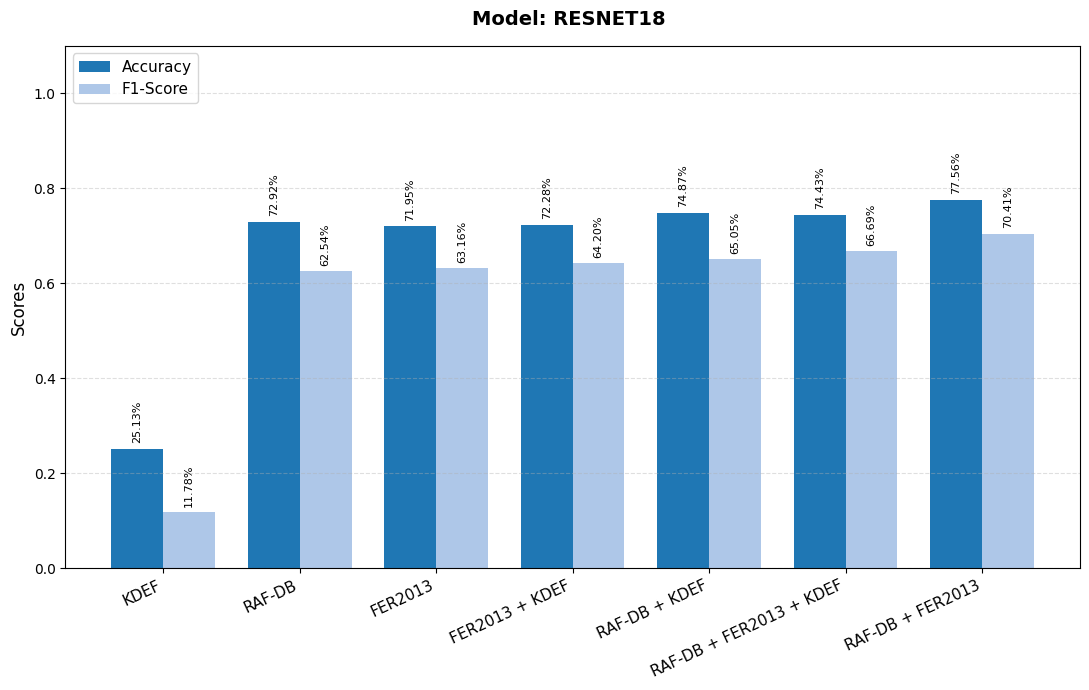

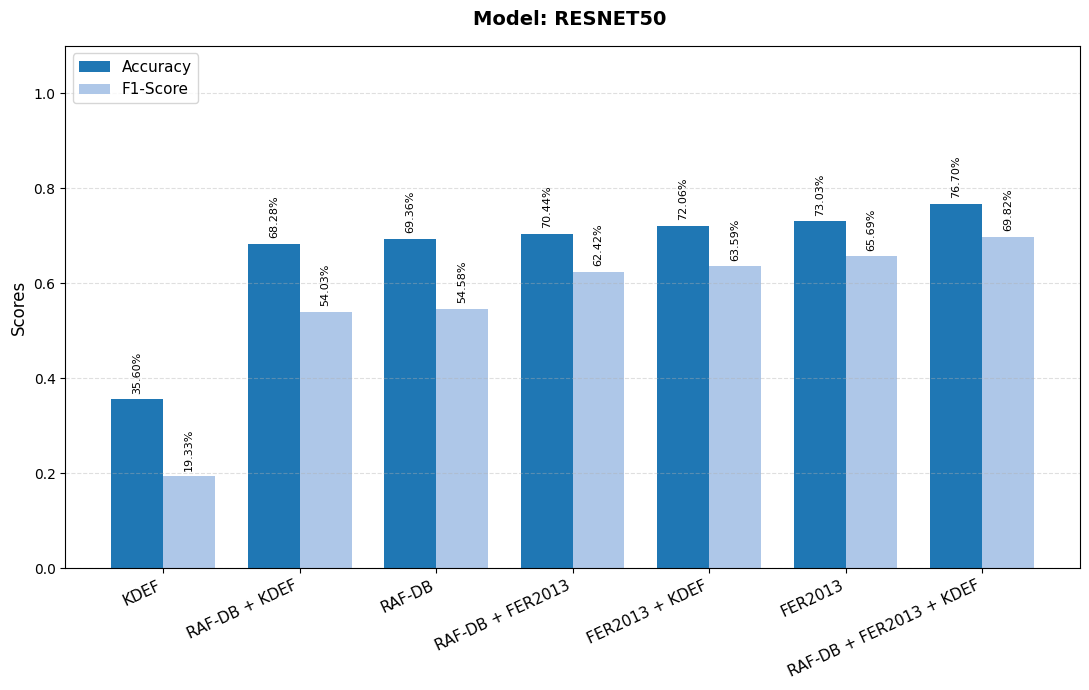

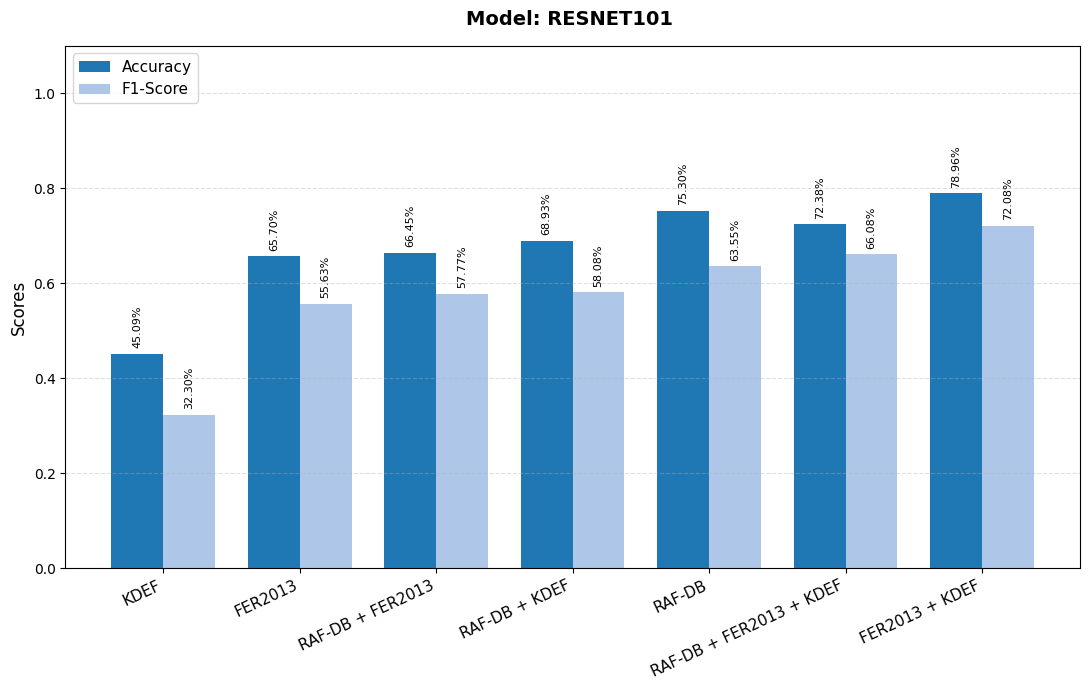

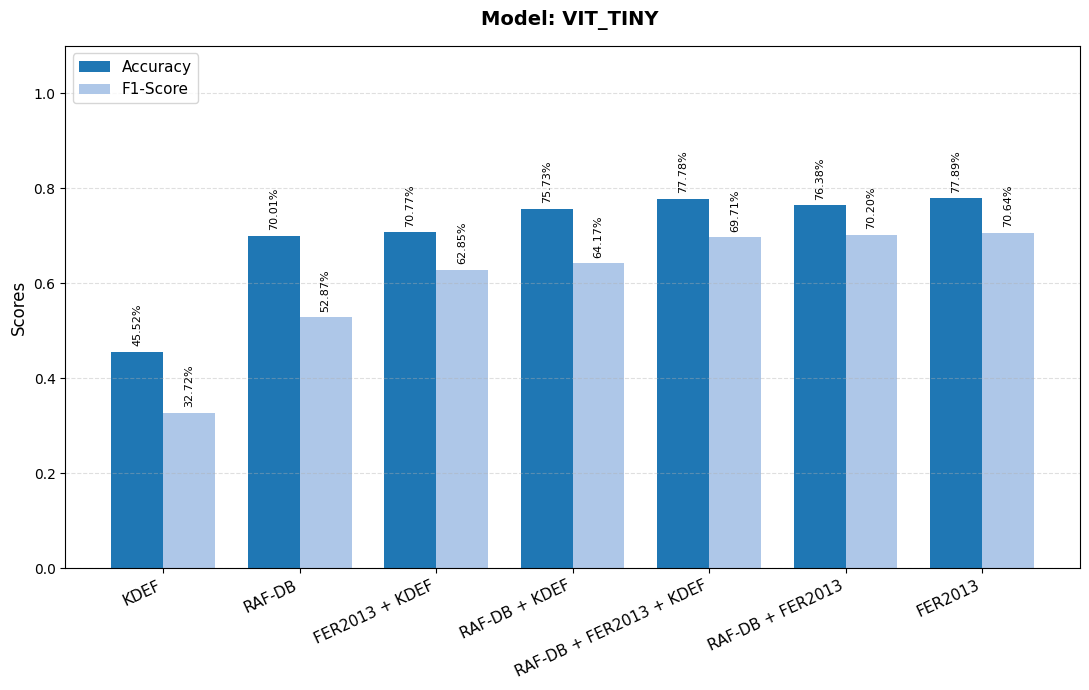

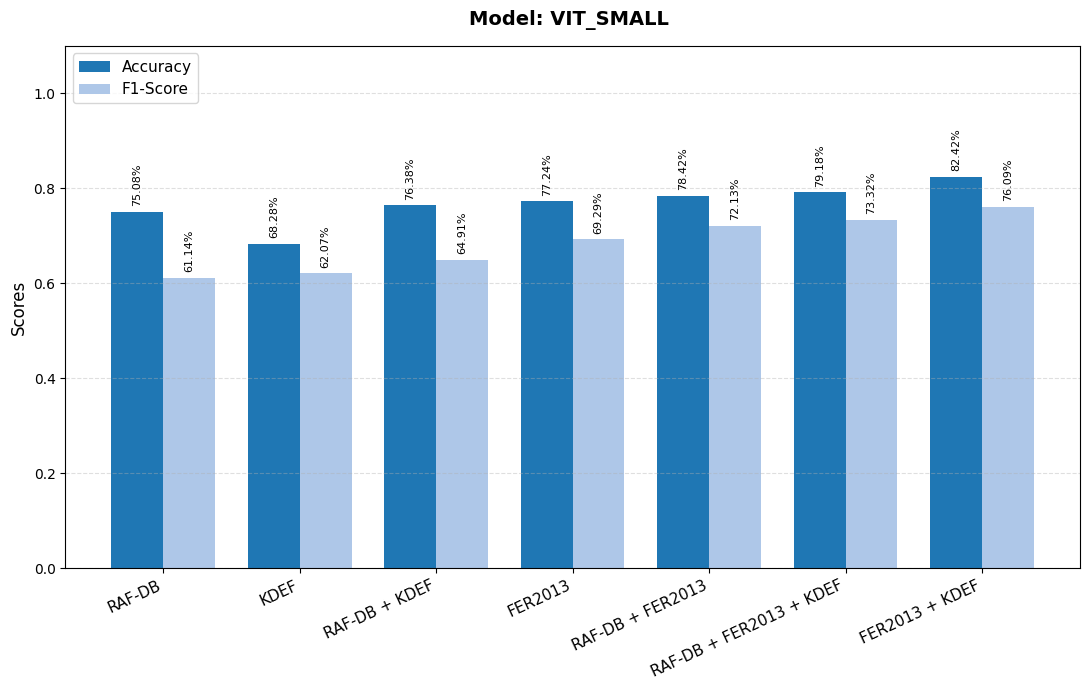

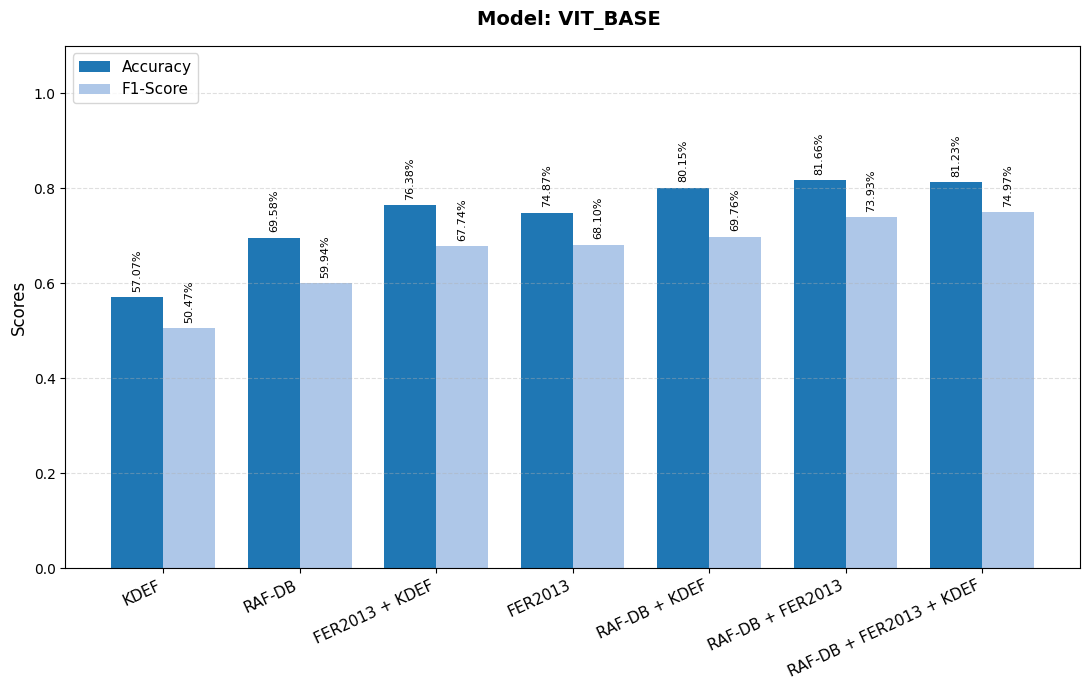

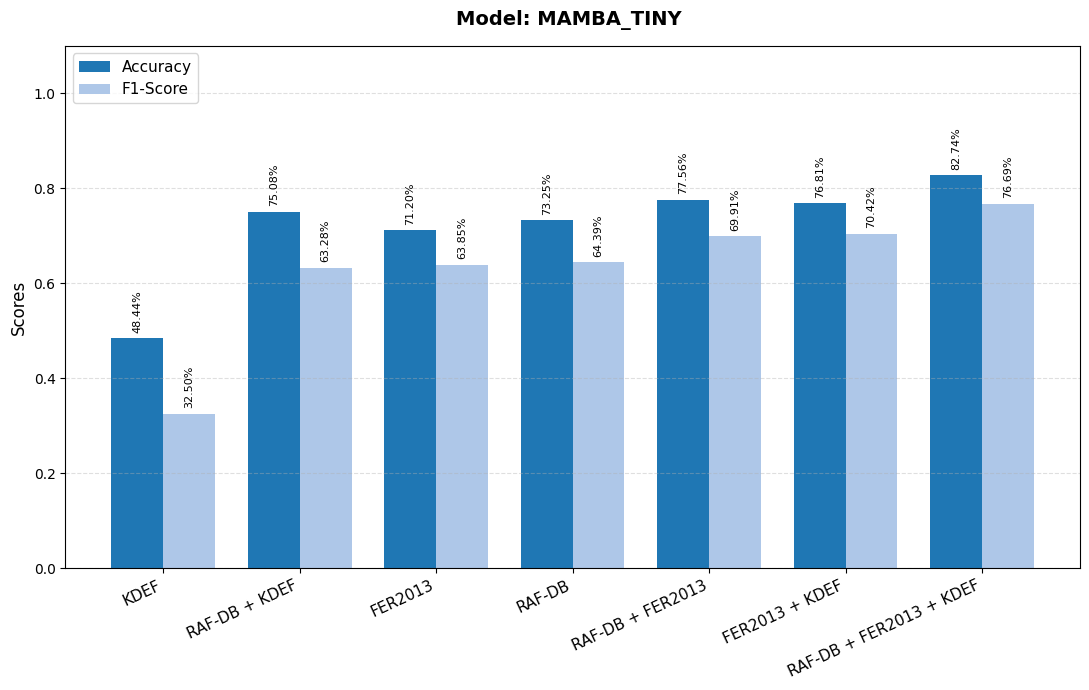

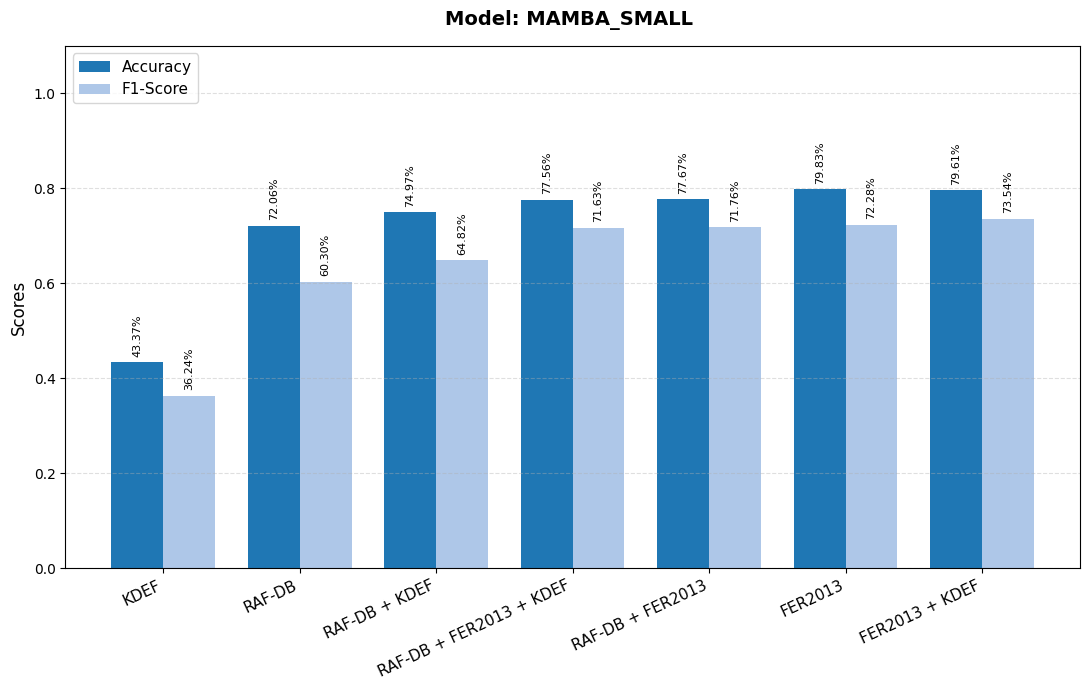

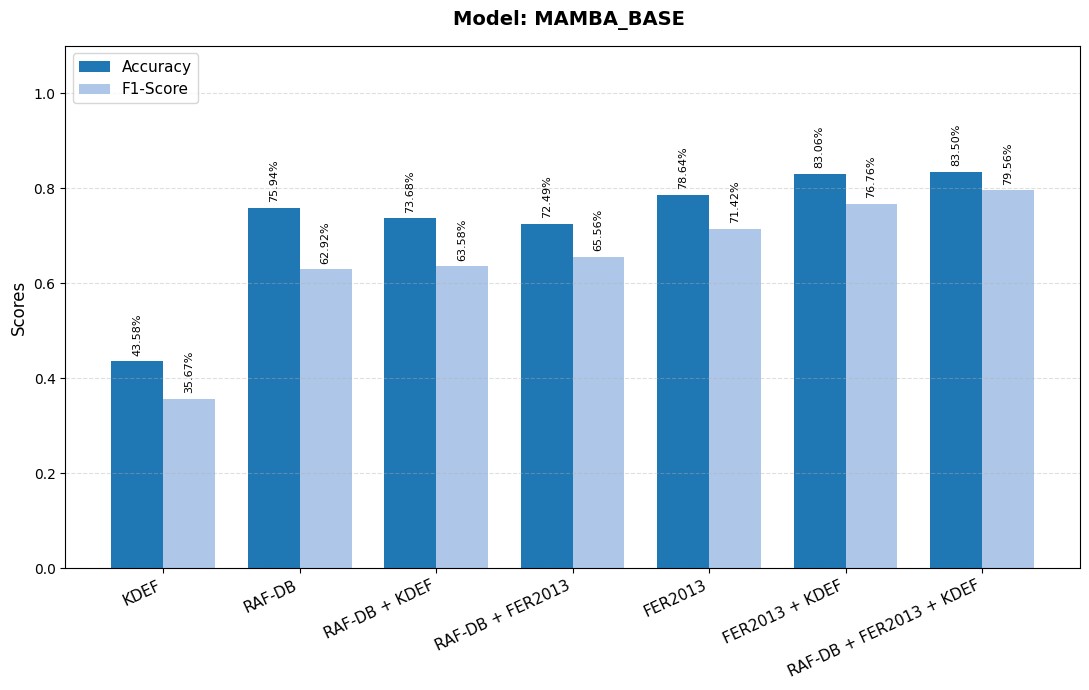

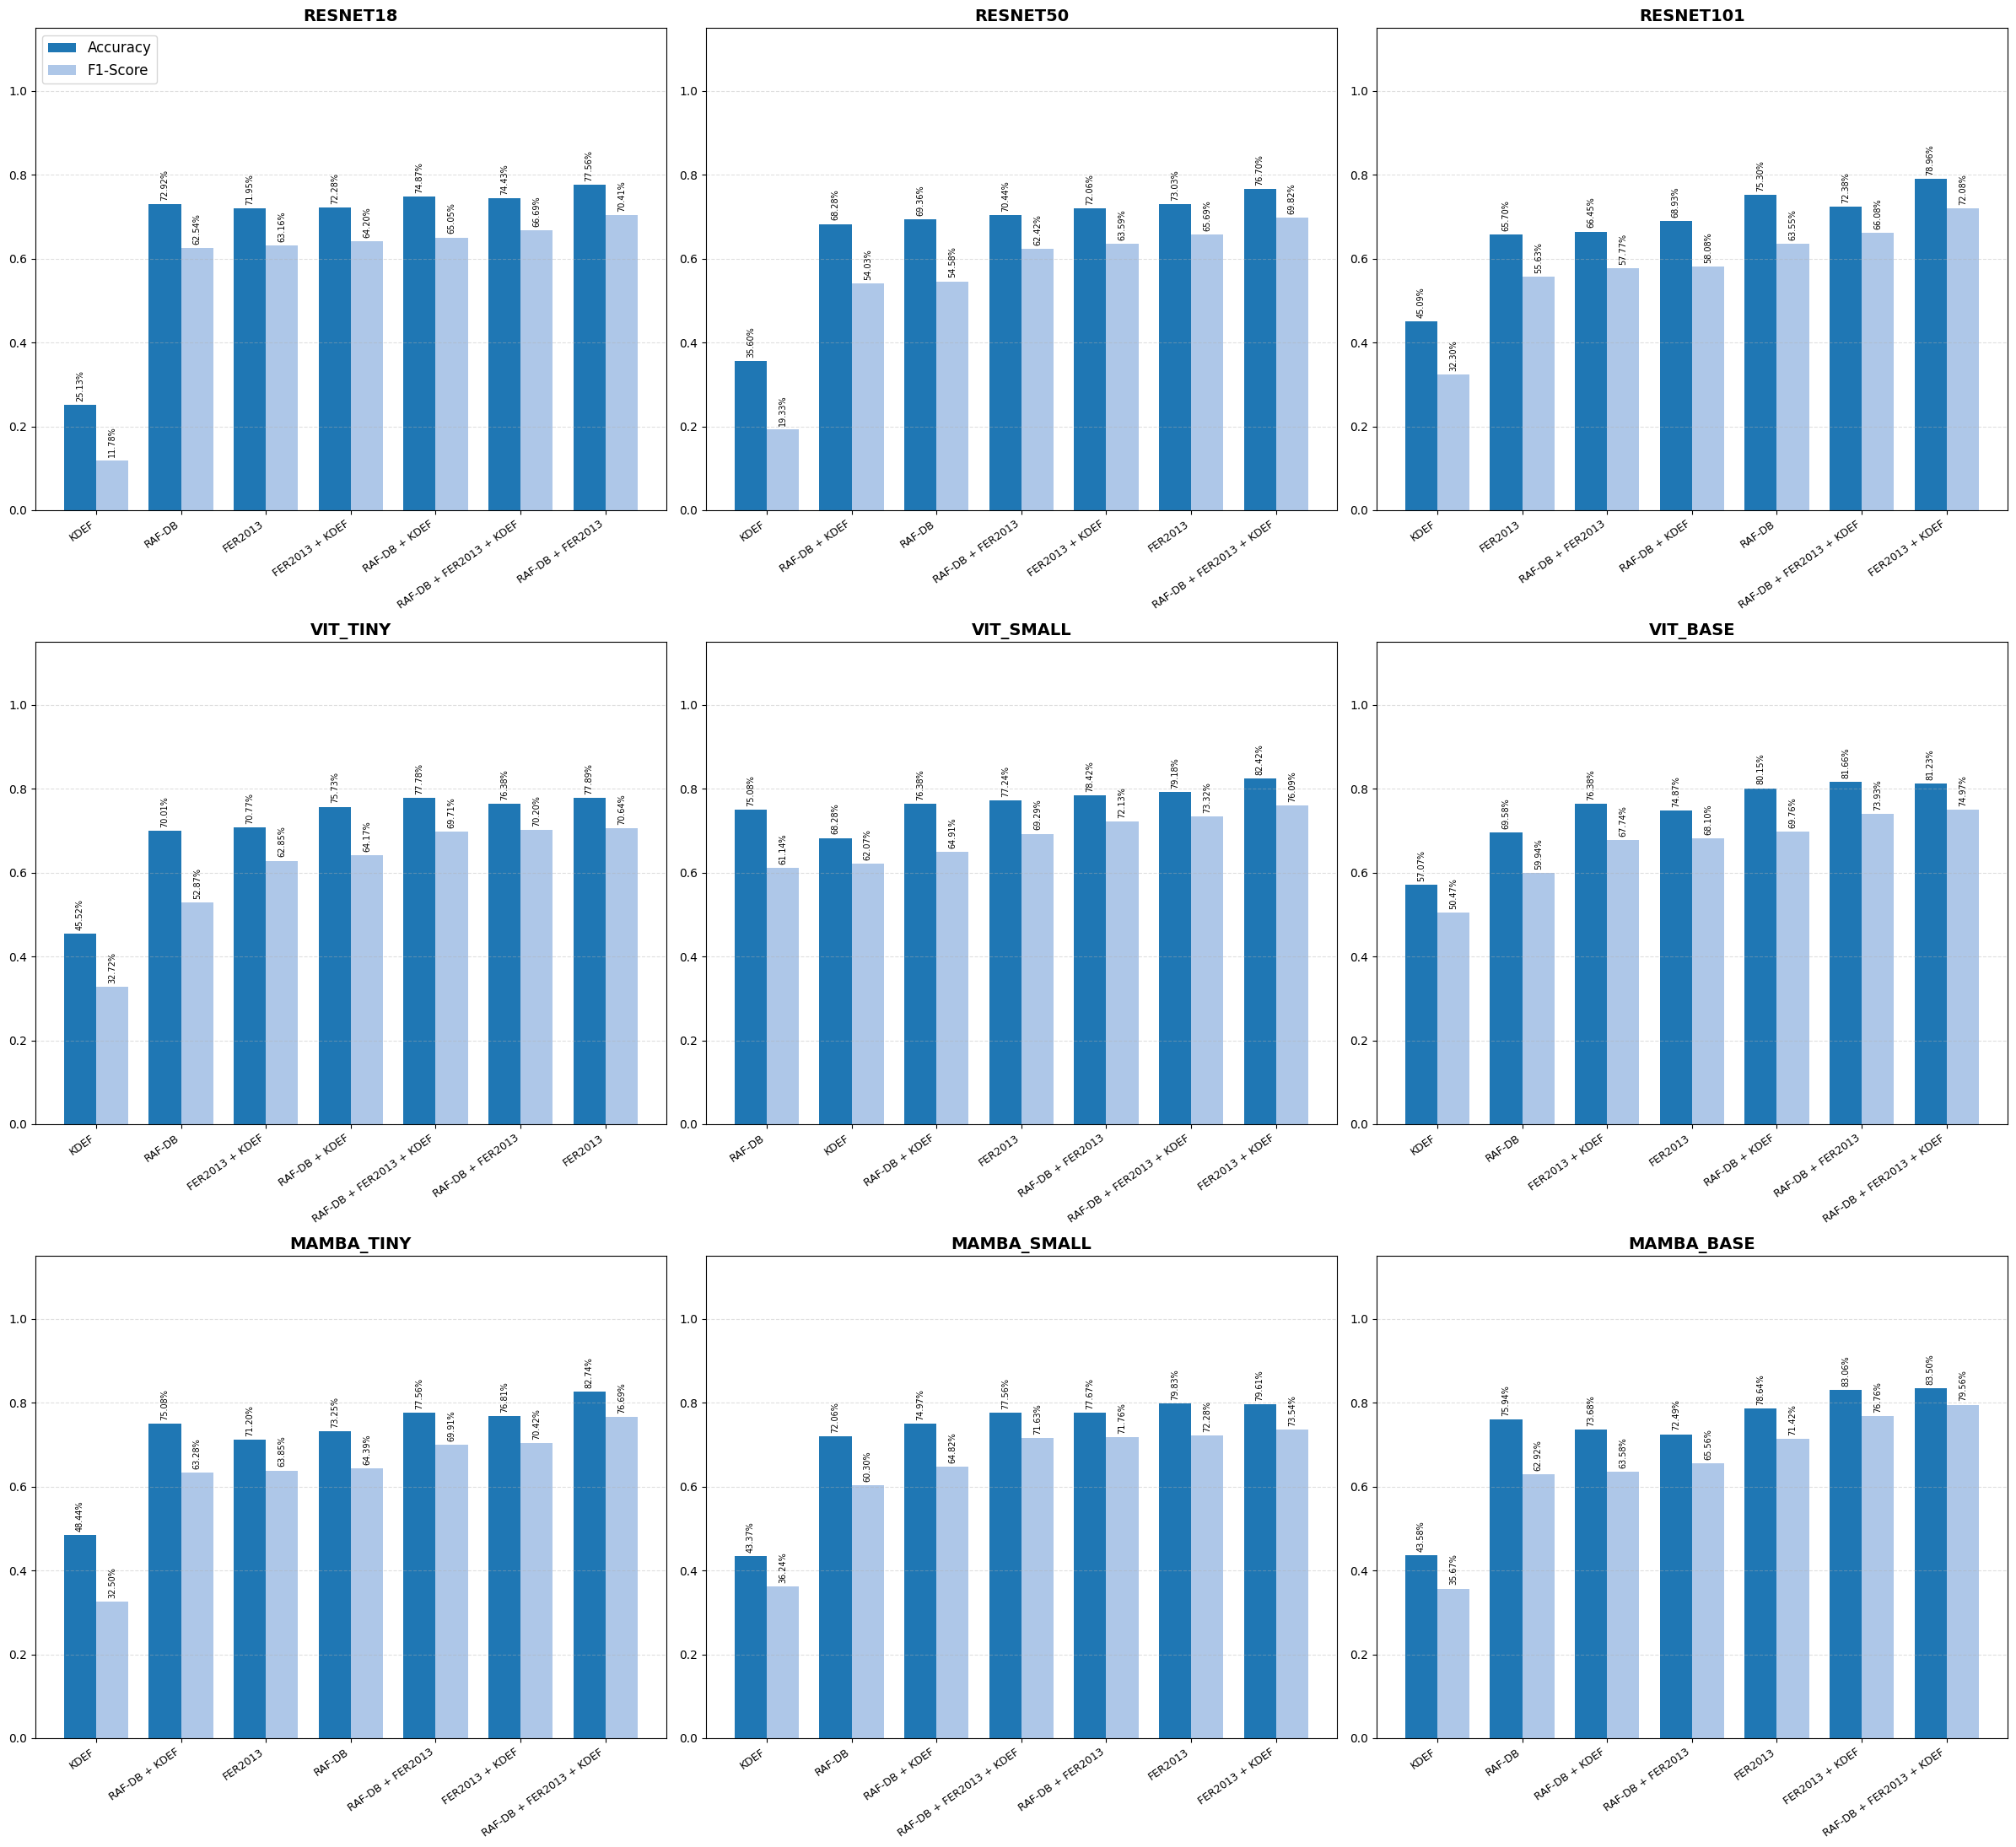

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data re-constructed accurately from the notebook
data = {
    'RAF-DB': {
        'resnet18': (0.729234, 0.625396), 'resnet50': (0.693635, 0.545828), 'resnet101': (0.752967, 0.635498),
        'vit_tiny': (0.700108, 0.528716), 'vit_small': (0.750809, 0.611399), 'vit_base': (0.695793, 0.599419),
        'mamba_tiny': (0.732470, 0.643927), 'mamba_small': (0.720604, 0.602966), 'mamba_base': (0.759439, 0.629200)
    },
    'KDEF': {
        'resnet18': (0.251348, 0.117780), 'resnet50': (0.355987, 0.193335), 'resnet101': (0.450917, 0.323013),
        'vit_tiny': (0.455232, 0.327161), 'vit_small': (0.682848, 0.620718), 'vit_base': (0.570658, 0.504702),
        'mamba_tiny': (0.484358, 0.325049), 'mamba_small': (0.433657, 0.362364), 'mamba_base': (0.435814, 0.356710)
    },
    'FER2013': {
        'resnet18': (0.719525, 0.631605), 'resnet50': (0.730313, 0.656857), 'resnet101': (0.656958, 0.556342),
        'vit_tiny': (0.778857, 0.706418), 'vit_small': (0.772384, 0.692947), 'vit_base': (0.748652, 0.680968),
        'mamba_tiny': (0.711974, 0.638497), 'mamba_small': (0.798274, 0.722782), 'mamba_base': (0.786408, 0.714193)
    },
    'RAF-DB + KDEF': {
        'resnet18': (0.748652, 0.650533), 'resnet50': (0.682848, 0.540298), 'resnet101': (0.689320, 0.580786),
        'vit_tiny': (0.757282, 0.641704), 'vit_small': (0.763754, 0.649139), 'vit_base': (0.801510, 0.697613),
        'mamba_tiny': (0.750809, 0.632842), 'mamba_small': (0.749730, 0.648201), 'mamba_base': (0.736785, 0.635778)
    },
    'FER2013 + KDEF': {
        'resnet18': (0.722762, 0.642020), 'resnet50': (0.720604, 0.635940), 'resnet101': (0.789644, 0.720782),
        'vit_tiny': (0.707659, 0.628494), 'vit_small': (0.824164, 0.760932), 'vit_base': (0.763754, 0.677388),
        'mamba_tiny': (0.768069, 0.704157), 'mamba_small': (0.796117, 0.735401), 'mamba_base': (0.830636, 0.767555)
    },
    'RAF-DB + FER2013': {
        'resnet18': (0.775620, 0.704065), 'resnet50': (0.704423, 0.624179), 'resnet101': (0.664509, 0.577664),
        'vit_tiny': (0.763754, 0.701968), 'vit_small': (0.784250, 0.721305), 'vit_base': (0.816613, 0.739295),
        'mamba_tiny': (0.775620, 0.699067), 'mamba_small': (0.776699, 0.717621), 'mamba_base': (0.724919, 0.655556)
    },
    'RAF-DB + FER2013 + KDEF': {
        'resnet18': (0.744337, 0.666893), 'resnet50': (0.766990, 0.698203), 'resnet101': (0.723840, 0.660820),
        'vit_tiny': (0.777778, 0.697068), 'vit_small': (0.791802, 0.733249), 'vit_base': (0.812298, 0.749659),
        'mamba_tiny': (0.827400, 0.766922), 'mamba_small': (0.775620, 0.716272), 'mamba_base': (0.834951, 0.795572)
    }
}

records = []
for dataset, models_dict in data.items():
    for model, (acc, f1) in models_dict.items():
        records.append({'Dataset': dataset, 'Model': model, 'Accuracy': acc, 'F1-Score': f1})
df = pd.DataFrame(records)

models = ['resnet18', 'resnet50', 'resnet101', 'vit_tiny', 'vit_small', 'vit_base', 'mamba_tiny', 'mamba_small', 'mamba_base']

# Colors as requested
c_acc = '#1f77b4'
c_f1 = '#aec7e8'

# Generate 9 separate individual charts
for model in models:
    fig, ax = plt.subplots(figsize=(11, 7))
    model_df = df[df['Model'] == model].sort_values(by='F1-Score', ascending=True)

    datasets = model_df['Dataset'].tolist()
    accuracies = model_df['Accuracy'].tolist()
    f1_scores = model_df['F1-Score'].tolist()

    x = np.arange(len(datasets))
    width = 0.38

    rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color=c_acc)
    rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color=c_f1)

    def annotate_bars(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height*100:.2f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 4), textcoords="offset points",
                        ha='center', va='bottom', fontsize=8, rotation=90)

    annotate_bars(rects1)
    annotate_bars(rects2)

    ax.set_title(f'Model: {model.upper()} ', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=25, ha='right', fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Scores', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(loc='upper left', fontsize=11)

    plt.tight_layout()
    plt.show() # Changed from savefig to show

# Combined panel
fig, axes = plt.subplots(3, 3, figsize=(24, 22))
axes = axes.flatten()

for i, model in enumerate(models):
    ax = axes[i]
    model_df = df[df['Model'] == model].sort_values(by='F1-Score', ascending=True)
    datasets = model_df['Dataset'].tolist()
    accuracies = model_df['Accuracy'].tolist()
    f1_scores = model_df['F1-Score'].tolist()
    x = np.arange(len(datasets))
    width = 0.38

    rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color=c_acc)
    rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color=c_f1)

    for rect in rects1:
        h = rect.get_height()
        ax.annotate(f'{h*100:.2f}%', xy=(rect.get_x() + rect.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=7, rotation=90)
    for rect in rects2:
        h = rect.get_height()
        ax.annotate(f'{h*100:.2f}%', xy=(rect.get_x() + rect.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=7, rotation=90)

    ax.set_title(f'{model.upper()}', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=35, ha='right', fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    if i == 0:
        ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.show() # Changed from savefig to show

Chart generated successfully.


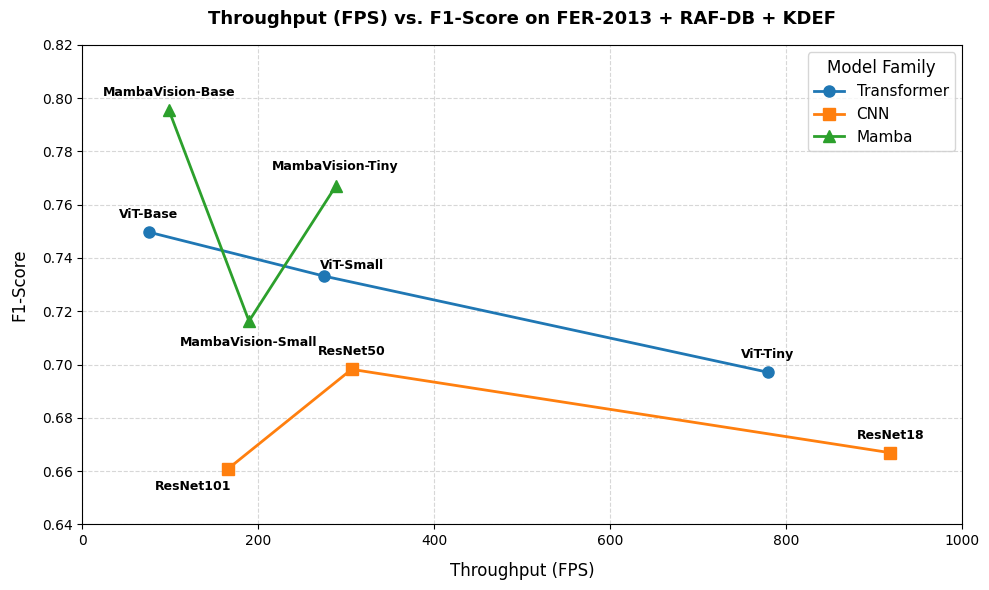

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Raw metrics dictionary for FER-2013 + RAF-DB + KDEF
raw_data_target = {
    "ResNet18": (74.43, 69.35, 67.82, 66.69),
    "ResNet50": (76.70, 72.37, 70.55, 69.82),
    "ResNet101": (72.38, 68.88, 68.37, 66.08),
    "ViT-Tiny": (77.78, 72.86, 71.90, 69.71),
    "ViT-Small": (79.18, 74.52, 74.29, 73.32),
    "ViT-Base": (81.23, 76.95, 74.41, 74.97),
    "MambaVision-Tiny": (82.74, 78.16, 77.57, 76.69),
    "MambaVision-Small": (77.56, 72.67, 73.56, 71.63),
    "MambaVision-Base": (83.50, 82.13, 80.75, 79.56),
}

# FPS dictionary from hardware profiling
fps_data = {
    "ResNet18": 917.98,
    "ResNet50": 305.82,
    "ResNet101": 165.15,
    "ViT-Tiny": 779.01,
    "ViT-Small": 274.47,
    "ViT-Base": 75.36,
    "MambaVision-Tiny": 287.72,
    "MambaVision-Small": 189.25,
    "MambaVision-Base": 98.08,
}

family_mapping = {
    "ResNet18": "CNN", "ResNet50": "CNN", "ResNet101": "CNN",
    "ViT-Tiny": "Transformer", "ViT-Small": "Transformer", "ViT-Base": "Transformer",
    "MambaVision-Tiny": "Mamba", "MambaVision-Small": "Mamba", "MambaVision-Base": "Mamba"
}

# Build Dataframe
rows = []
for model, metrics in raw_data_target.items():
    rows.append({
        "Model": model,
        "Family": family_mapping[model],
        "F1-Score": metrics[3] / 100.0,  # convert to decimal standard format
        "FPS": fps_data[model]
    })

df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 6))

families = ["Transformer", "CNN", "Mamba"]
colors = {'Transformer': '#1f77b4', 'CNN': '#ff7f0e', 'Mamba': '#2ca02c'}
markers = {'Transformer': 'o', 'CNN': 's', 'Mamba': '^'}

for family in families:
    family_df = df[df['Family'] == family].sort_values(by='FPS', ascending=False)
    ax.plot(family_df['FPS'], family_df['F1-Score'], label=family, color=colors[family], marker=markers[family], linewidth=2, markersize=8)

    for _, row in family_df.iterrows():
        xytext = (0, 10)
        if row['Model'] == 'MambaVision-Small':
            xytext = (0, -18)
        elif row['Model'] == 'ResNet101':
            xytext = (-25, -15)
        elif row['Model'] == 'ViT-Small':
            xytext = (20, 5)
        elif row['Model'] == 'MambaVision-Tiny':
            xytext = (0, 12)

        ax.annotate(row['Model'],
                    (row['FPS'], row['F1-Score']),
                    textcoords="offset points",
                    xytext=xytext,
                    ha='center',
                    fontsize=9,
                    weight='bold')

ax.set_xlabel('Throughput (FPS)', fontsize=12, labelpad=10)
ax.set_ylabel('F1-Score', fontsize=12, labelpad=10)
ax.set_title('Throughput (FPS) vs. F1-Score on FER-2013 + RAF-DB + KDEF', fontsize=13, pad=15, weight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Model Family', fontsize=11, title_fontsize=12, loc='upper right')

ax.set_xlim(0, 1000)
ax.set_ylim(0.64, 0.82)

plt.tight_layout()
plt.savefig('fer_raf_kdef_fps_vs_f1.png', dpi=300)
print("Chart generated successfully.")

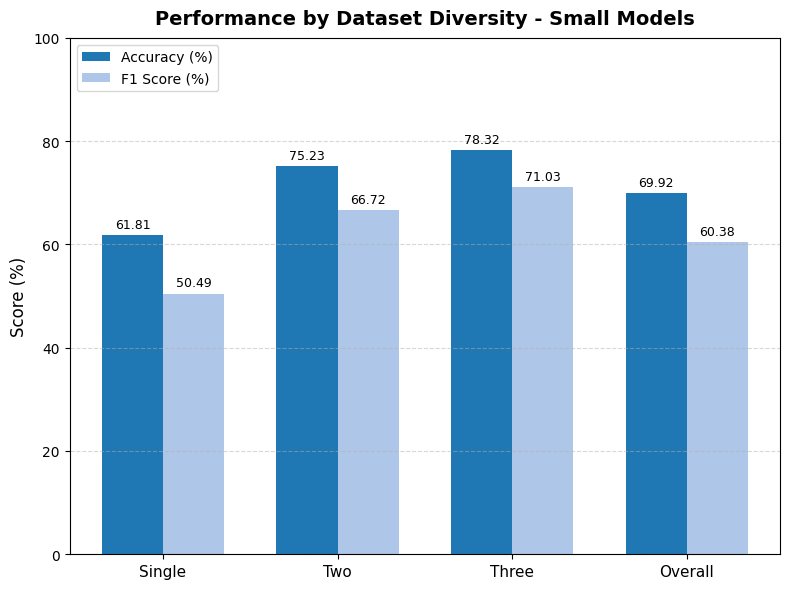

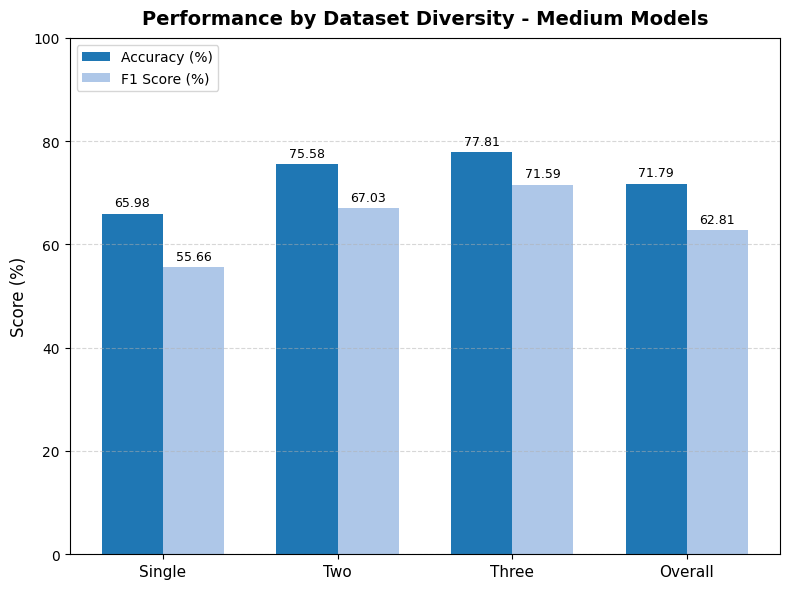

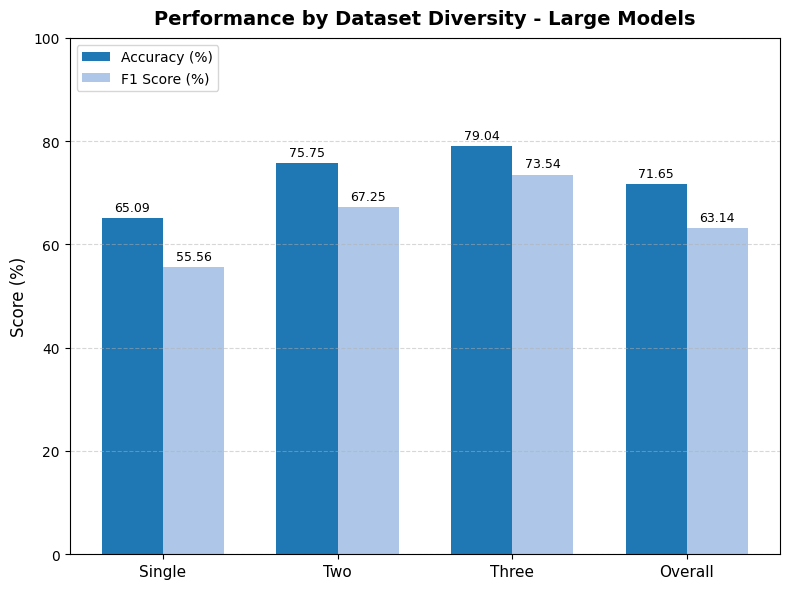

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# We use table_4_8 which is already in your environment
categories = ['Single', 'Two', 'Three', 'Overall']

c_acc = '#1f77b4'
c_f1 = '#aec7e8'
x = np.arange(len(categories))
width = 0.35

for i, row in table_4_8.iterrows():
    size = row['Model Size']

    acc_scores = [
        row['Single Accuracy (%)'],
        row['Two Accuracy (%)'],
        row['Three Accuracy (%)'],
        row['Overall Accuracy (%)']
    ]

    f1_scores = [
        row['Single F1 (%)'],
        row['Two F1 (%)'],
        row['Three F1 (%)'],
        row['Overall F1 (%)']
    ]

    fig, ax = plt.subplots(figsize=(8, 6))
    rects1 = ax.bar(x - width/2, acc_scores, width, label='Accuracy (%)', color=c_acc)
    rects2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score (%)', color=c_f1)

    ax.set_title(f'Performance by Dataset Diversity - {size} Models', fontsize=14, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylim(0, 100)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Add value annotations on top of the bars
    for rect in rects1 + rects2:
        h = rect.get_height()
        ax.annotate(f'{h:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

    ax.set_ylabel('Score (%)', fontsize=12)
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()


In [ ]:
!pip install mambavision --no-deps -q
!pip install timm -q
!pip install "Pillow<11.0.0" -q
!pip install statsmodels -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 47.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mambavision 1.2.0 requires einops==0.8.1, but you have einops 0.8.2 which is incompatible.
mambavision 1.2.0 requires mamba-ssm==2.2.4, but you have mamba-ssm 2.3.2.post1 which is incompatible.
mambavision 1.2.0 requires Pillow==11.1.0, but you have pillow 10.4.0 which is incompatible.
mambavision 1.2.0 requires requests==2.32.3, but you have requests 2.32.4 which is incompatible.
mambavision 1.2.0 requires timm==1.0.15, but you have timm 1.0.27 which is incompatible.
mambavision 1.2.0 requires transformers==4.50.0, but you have transformers 5.12.1 which is incompatible.


In [ ]:
import torch
import timm
import os
import numpy as np
from torch.utils.data import DataLoader, Dataset
from mambavision import create_model as create_mamba_model
from statsmodels.stats.contingency_tables import mcnemar


# ============================================================
# STEP 0 — Verify available MambaVision model names
# Run this block FIRST to confirm exact arch strings
# ============================================================


# ============================================================
# CLASS MAPPING — 6 emotions (contempt excluded from CK+)
# NOTE: PTFolderDataset will print a warning for any folder
# that does not match a known emotion class (e.g., 'contempt')
# so you can verify no unexpected classes are silently dropped.
# ============================================================
CLASS_MAPPING = {
    'angry':    0,
    'disgust':  1,
    'fear':     2,
    'happy':    3,
    'sad':      4,
    'surprise': 5
}


# ============================================================
# DATASET
# ============================================================
class PTFolderDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []
        skipped_folders = []

        for cls_name in os.listdir(root_dir):
            cls_dir = os.path.join(root_dir, cls_name)
            if not os.path.isdir(cls_dir):
                continue

            target_label = None
            for t_name, t_idx in CLASS_MAPPING.items():
                if t_name.lower() in cls_name.lower():
                    target_label = t_idx
                    break

            if target_label is None:
                skipped_folders.append(cls_name)
                continue

            for file in os.listdir(cls_dir):
                if file.endswith('.pt'):
                    self.samples.append((os.path.join(cls_dir, file), target_label))

        # Warn about any folders that did not match a class
        # (e.g., 'contempt' in CK+, which is excluded by design)
        if skipped_folders:
            print(f"[WARNING] The following folders were SKIPPED "
                  f"(not in CLASS_MAPPING): {skipped_folders}")

        print(f"[INFO] Loaded {len(self.samples)} samples "
              f"from {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        tensor = torch.load(path, map_location='cpu')
        if tensor.dim() == 4 and tensor.size(0) == 1:
            tensor = tensor.squeeze(0)
        return tensor, label


# ============================================================
# DATALOADER
# ============================================================
dataset_path = '/content/drive/MyDrive/processed_ck_pt/CK+48'

if os.path.exists(dataset_path):
    test_dataset = PTFolderDataset(dataset_path)
    test_loader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )
else:
    raise FileNotFoundError(
        f"Dataset path does not exist: {dataset_path}\n"
        "Please mount your Google Drive first."
    )


# ============================================================
# MODEL PATHS
# ============================================================
model_dir    = '/content/drive/MyDrive/Saved_Model/RAF-DB+FER2013+KDEF/'
model_a_path = os.path.join(model_dir, 'mamba_base_best.pth')
model_b_path = os.path.join(model_dir, 'vit_small_best.pth')


# ============================================================
# INFERENCE
# ============================================================
def get_real_predictions(model_path, arch_name, num_classes=6):
    """
    Loads a saved model checkpoint, runs inference on the CK+ test set,
    and returns (true_labels, predicted_labels) as numpy arrays.

    Parameters
    ----------
    model_path : str  — path to the saved .pth checkpoint
    arch_name  : str  — timm or mambavision model identifier
    num_classes: int  — number of output classes (default 6)
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n[INFO] Running inference for '{arch_name}' on {device}")

    # --- Instantiate model skeleton ---
    if 'mamba' in arch_name.lower():
        model = create_mamba_model(arch_name, pretrained=False, num_classes=num_classes)
    else:
        model = timm.create_model(arch_name, pretrained=False, num_classes=num_classes)

    # --- Load checkpoint ---
    state_dict = torch.load(model_path, map_location=device)

    # Some ResNet checkpoints wrap the head as fc.1 instead of fc
    # (only relevant if you test ResNets with this same function)
    if 'fc.1.weight' in state_dict:
        state_dict['fc.weight'] = state_dict.pop('fc.1.weight')
    if 'fc.1.bias' in state_dict:
        state_dict['fc.bias'] = state_dict.pop('fc.1.bias')

    # Load with strict=False and report any anomalies so silent
    # failures are immediately visible
    missing_keys, unexpected_keys = model.load_state_dict(state_dict, strict=False)
    if missing_keys:
        print(f"[WARNING] Missing keys in checkpoint for '{arch_name}':\n"
              f"  {missing_keys}")
    if unexpected_keys:
        print(f"[WARNING] Unexpected keys in checkpoint for '{arch_name}':\n"
              f"  {unexpected_keys}")
    if not missing_keys and not unexpected_keys:
        print(f"[INFO] Checkpoint loaded cleanly — no missing or unexpected keys.")

    model.to(device)
    model.eval()

    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Free GPU memory immediately after inference
    del model
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    return np.array(all_labels), np.array(all_preds)


# ============================================================
# MCNEMAR'S TEST
# Reference for exact-vs-asymptotic threshold:
#   Agresti, A. (2002). Categorical Data Analysis (2nd ed.), p.411
#   Exact binomial test used when discordant pairs < 25;
#   continuity-corrected chi-squared otherwise.
# ============================================================

def run_mcnemar_test(
    y_true,
    y_pred_model_a,
    y_pred_model_b,
    model_a_name="Model A",
    model_b_name="Model B",
    alpha=0.05
):
    y_true = np.asarray(y_true)
    y_pred_a = np.asarray(y_pred_model_a)
    y_pred_b = np.asarray(y_pred_model_b)

    assert len(y_true) == len(y_pred_a) == len(y_pred_b), "Length mismatch."

    a_correct = (y_pred_a == y_true)
    b_correct = (y_pred_b == y_true)

    both_correct      = int(np.sum( a_correct &  b_correct))
    a_correct_b_wrong = int(np.sum( a_correct & ~b_correct))
    a_wrong_b_correct = int(np.sum(~a_correct &  b_correct))
    both_wrong        = int(np.sum(~a_correct & ~b_correct))

    table = [
        [both_correct,      a_correct_b_wrong],
        [a_wrong_b_correct, both_wrong]
    ]

    b = a_correct_b_wrong
    c = a_wrong_b_correct
    n_discordant = b + c

    if n_discordant == 0:
        print("No discordant pairs. The two models have identical correctness outcomes.")
        return {
            "table": table,
            "n_discordant": 0,
            "p_value": 1.0,
            "method": "Not applicable: no discordant pairs"
        }

    if n_discordant < 25:
        result = mcnemar(table, exact=True)
        method = "Exact binomial McNemar test"
        statistic = None
    else:
        result = mcnemar(table, exact=False, correction=True)
        method = "Chi-square McNemar test with Yates continuity correction"
        statistic = result.statistic

    p_value = result.pvalue

    print("\n" + "=" * 65)
    print(f"MCNEMAR TEST: {model_a_name} vs {model_b_name}")
    print("=" * 65)
    print("Contingency table:")
    print(f"                    {model_b_name} Correct    {model_b_name} Wrong")
    print(f"{model_a_name} Correct        {both_correct:5d}              {a_correct_b_wrong:5d}")
    print(f"{model_a_name} Wrong          {a_wrong_b_correct:5d}              {both_wrong:5d}")
    print("-" * 65)
    print(f"Discordant pairs: {n_discordant}")
    print(f"Method: {method}")
    print(f"Statistic: {'N/A' if statistic is None else round(statistic, 4)}")
    print(f"p-value: {p_value:.6f}")

    if p_value < alpha:
        print(f"Conclusion: Reject H0 at alpha={alpha}.")
        if b > c:
            print(f"{model_a_name} has significantly fewer errors on this test set.")
        elif c > b:
            print(f"{model_b_name} has significantly fewer errors on this test set.")
        else:
            print("Significant result but equal discordant counts is unusual; check data.")
    else:
        print(f"Conclusion: Fail to reject H0 at alpha={alpha}.")
        print("No statistically significant difference in paired error rates.")

    return {
        "both_correct": both_correct,
        "a_correct_b_wrong": a_correct_b_wrong,
        "a_wrong_b_correct": a_wrong_b_correct,
        "both_wrong": both_wrong,
        "n_discordant": n_discordant,
        "p_value": p_value,
        "method": method,
        "statistic": statistic
    }



# ============================================================
# MAIN — Get predictions, then run the test
# NOTE: Verify 'mamba_vision_B' against mambavision.list_models()
#       output above before running this block.
# ============================================================
print("=" * 65)
print("Extracting predictions — MambaVision-Base")
print("=" * 65)
y_true, y_pred_mamba = get_real_predictions(
    model_path=model_a_path,
    arch_name='mamba_vision_B'       # <-- confirm this string above
)

print("=" * 65)
print("Extracting predictions — ViT-Small")
print("=" * 65)
_, y_pred_vit = get_real_predictions(
    model_path=model_b_path,
    arch_name='vit_small_patch16_224'
)

# Sanity check: both runs must produce the same number of samples
assert len(y_true) == len(y_pred_mamba) == len(y_pred_vit), (
    f"Sample count mismatch! "
    f"y_true={len(y_true)}, mamba={len(y_pred_mamba)}, vit={len(y_pred_vit)}"
)
print(f"\n[INFO] Total test samples evaluated: {len(y_true)}")

# Run McNemar's test
results = run_mcnemar_test(
    y_true         = y_true,
    y_pred_model_a = y_pred_mamba,
    y_pred_model_b = y_pred_vit,
    model_a_name   = "MambaVision-Base",
    model_b_name   = "ViT-Small"
)

/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[INFO] Loaded 927 samples from /content/drive/MyDrive/processed_ck_pt/CK+48
Extracting predictions — MambaVision-Base

[INFO] Running inference for 'mamba_vision_B' on cuda
[INFO] Checkpoint loaded cleanly — no missing or unexpected keys.
Extracting predictions — ViT-Small

[INFO] Running inference for 'vit_small_patch16_224' on cuda
[INFO] Checkpoint loaded cleanly — no missing or unexpected keys.

[INFO] Total test samples evaluated: 927

MCNEMAR TEST: MambaVision-Base vs ViT-Small
Contingency table:
                    ViT-Small Correct    ViT-Small Wrong
MambaVision-Base Correct          682                 92
MambaVision-Base Wrong             52                101
-----------------------------------------------------------------
Discordant pairs: 144
Method: Chi-square McNemar test with Yates continuity correction
Statistic: 10.5625
p-value: 0.001154
Conclusion: Reject H0 at alpha=0.05.
MambaVision-Base has significantly fewer errors on this test set.


In [ ]:
from google.colab import runtime
runtime.unassign()